<a href="https://colab.research.google.com/github/AncaraniJuanDiego/AnalisisSeriesTemporales/blob/main/SeriesTP_PriceClosing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Practico Analisis en series temporales.

Juan Diego Ancarani

Explicación: https://www.youtube.com/watch?v=01DSVWN5xhQ

16/4/2026


¿Que es la accion 'JSWSTEEL'?→ corresponde a una acción real (históricamente relacionada con una empresa siderurgíca).




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import warnings
import time

#Series temporales.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller, kpss


plt.style.use('seaborn-v0_8-whitegrid')
TIME_STEPS = 200
DRIFT= 0.5

In [2]:
#Carga

df = pd.read_excel('JSWSTEEL.xlsx')
df

,Date,Company,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume
0,2005-03-23,JSWSTEEL,EQ,10.00,455.00,458.50,383.60,386.90,390.15,419.86,2087710
1,2005-03-24,JSWSTEEL,EQ,390.15,392.85,398.50,357.50,371.80,369.20,372.01,1226479
2,2005-03-28,JSWSTEEL,EQ,369.20,376.70,394.05,375.00,380.00,378.85,383.64,1235794
3,2005-03-29,JSWSTEEL,EQ,378.85,382.90,383.80,363.25,369.10,368.05,375.26,624072
4,2005-03-30,JSWSTEEL,EQ,368.05,367.00,371.90,360.05,362.70,362.15,365.13,466349
...,...,...,...,...,...,...,...,...,...,...,...
3989,2021-04-26,JSWSTEEL,EQ,635.40,642.00,660.70,638.25,657.00,655.80,651.46,16506538
3990,2021-04-27,JSWSTEEL,EQ,655.80,660.65,670.35,658.00,666.35,665.90,664.15,15799458
3991,2021-04-28,JSWSTEEL,EQ,665.90,669.75,676.00,650.65,662.50,662.65,661.63,15558949
3992,2021-04-29,JSWSTEEL,EQ,662.65,672.00,728.90,668.05,726.20,726.50,704.40,56816962


In [3]:
#Convertir columna 'Volume' en millones → para que los numeros no sean tan grandes.

df['Volume_Mill'] = df['Volume'] / 1000000
df.drop('Volume', axis=1, inplace=True)

In [4]:
#Feature 1: Intraday_change
df['Intraday_change'] = df['Close'] - df['Open']

#Feature 2: Volatil_range

df['Volatile_range'] = df['High'] - df['Low']

#Feature 3: %_DayTrading (movimientos dentro del dia)
df['%_DayTrading'] = (df['Close'] - df['Open']) / df['Open'] * 100

In [5]:
df

,Date,Company,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume_Mill,Intraday_change,Volatile_range,%_DayTrading
0,2005-03-23,JSWSTEEL,EQ,10.00,455.00,458.50,383.60,386.90,390.15,419.86,2.087710,-64.85,74.90,-14.252747
1,2005-03-24,JSWSTEEL,EQ,390.15,392.85,398.50,357.50,371.80,369.20,372.01,1.226479,-23.65,41.00,-6.020109
2,2005-03-28,JSWSTEEL,EQ,369.20,376.70,394.05,375.00,380.00,378.85,383.64,1.235794,2.15,19.05,0.570746
3,2005-03-29,JSWSTEEL,EQ,378.85,382.90,383.80,363.25,369.10,368.05,375.26,0.624072,-14.85,20.55,-3.878297
4,2005-03-30,JSWSTEEL,EQ,368.05,367.00,371.90,360.05,362.70,362.15,365.13,0.466349,-4.85,11.85,-1.321526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3989,2021-04-26,JSWSTEEL,EQ,635.40,642.00,660.70,638.25,657.00,655.80,651.46,16.506538,13.80,22.45,2.149533
3990,2021-04-27,JSWSTEEL,EQ,655.80,660.65,670.35,658.00,666.35,665.90,664.15,15.799458,5.25,12.35,0.794672
3991,2021-04-28,JSWSTEEL,EQ,665.90,669.75,676.00,650.65,662.50,662.65,661.63,15.558949,-7.10,25.35,-1.060097
3992,2021-04-29,JSWSTEEL,EQ,662.65,672.00,728.90,668.05,726.20,726.50,704.40,56.816962,54.50,60.85,8.110119


# 1. Grafique la serie original. ¿Visualmente parece estacionaria? ¿Qué características observa?

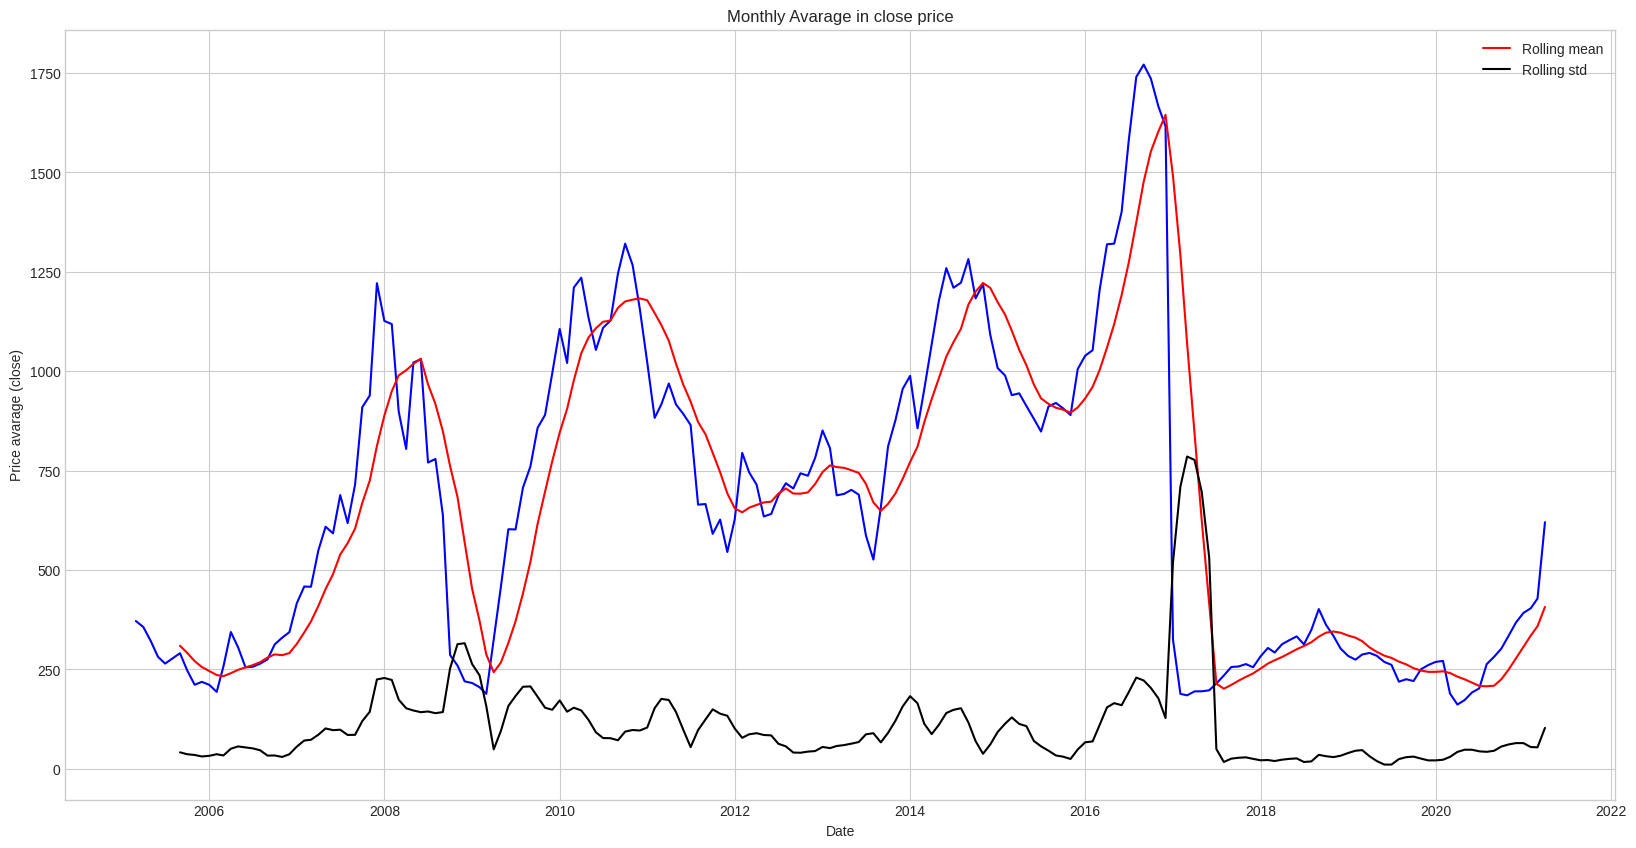

,Close
count,194.000000
mean,658.881026
std,393.596369
min,161.813889
25%,284.890568
50%,631.253409
75%,939.427922
max,1770.820000


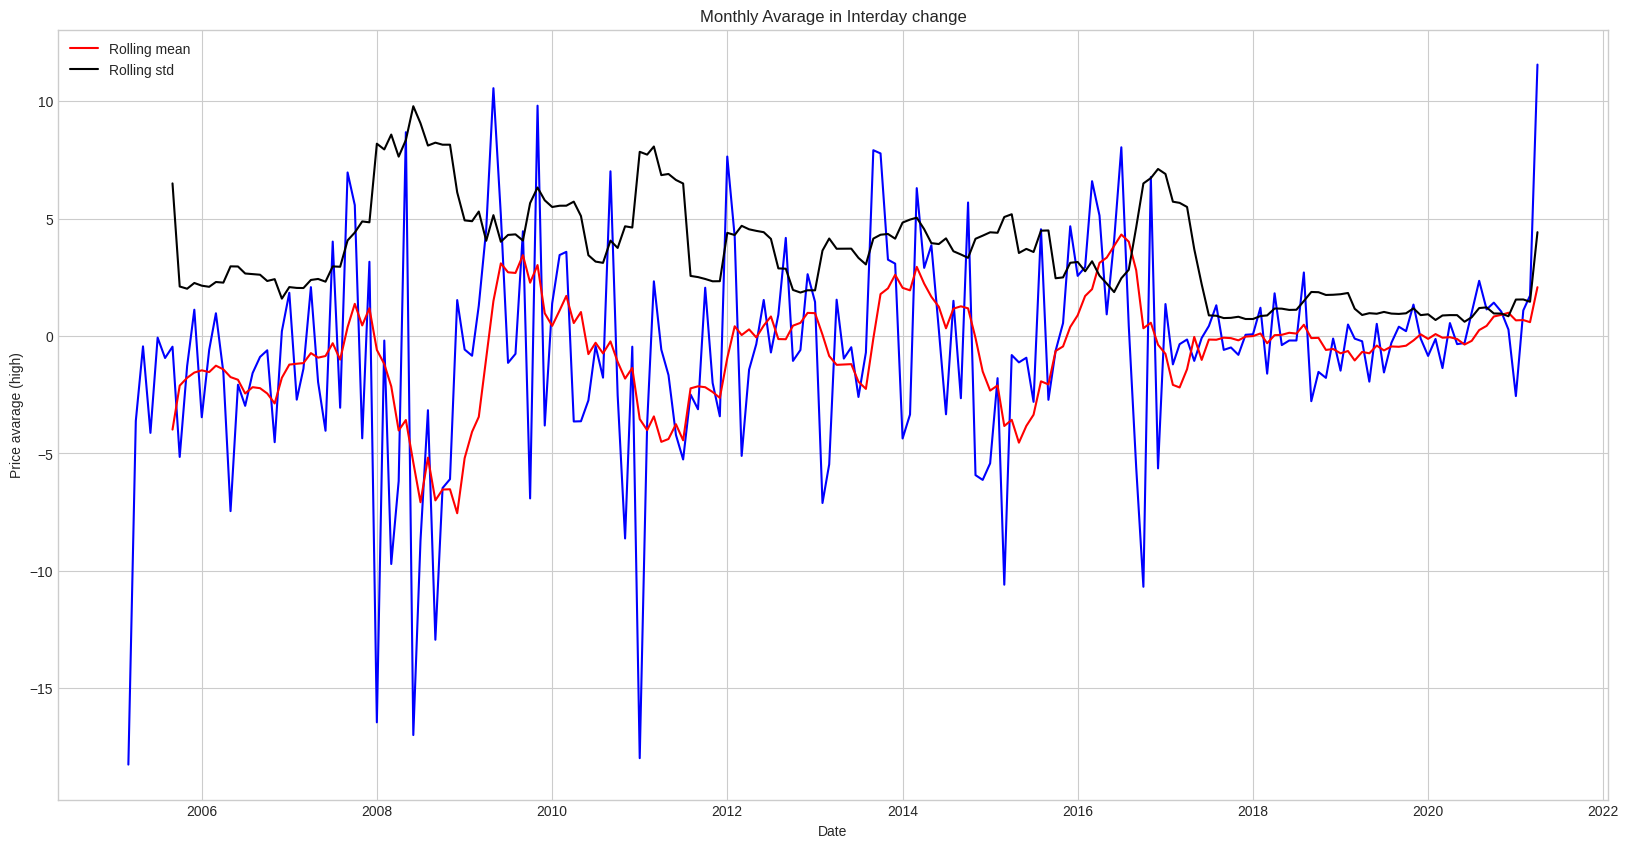

,Intraday_change
count,194.000000
mean,-0.685416
std,4.575410
min,-18.258333
25%,-2.697937
50%,-0.468571
75%,1.410996
max,11.560526


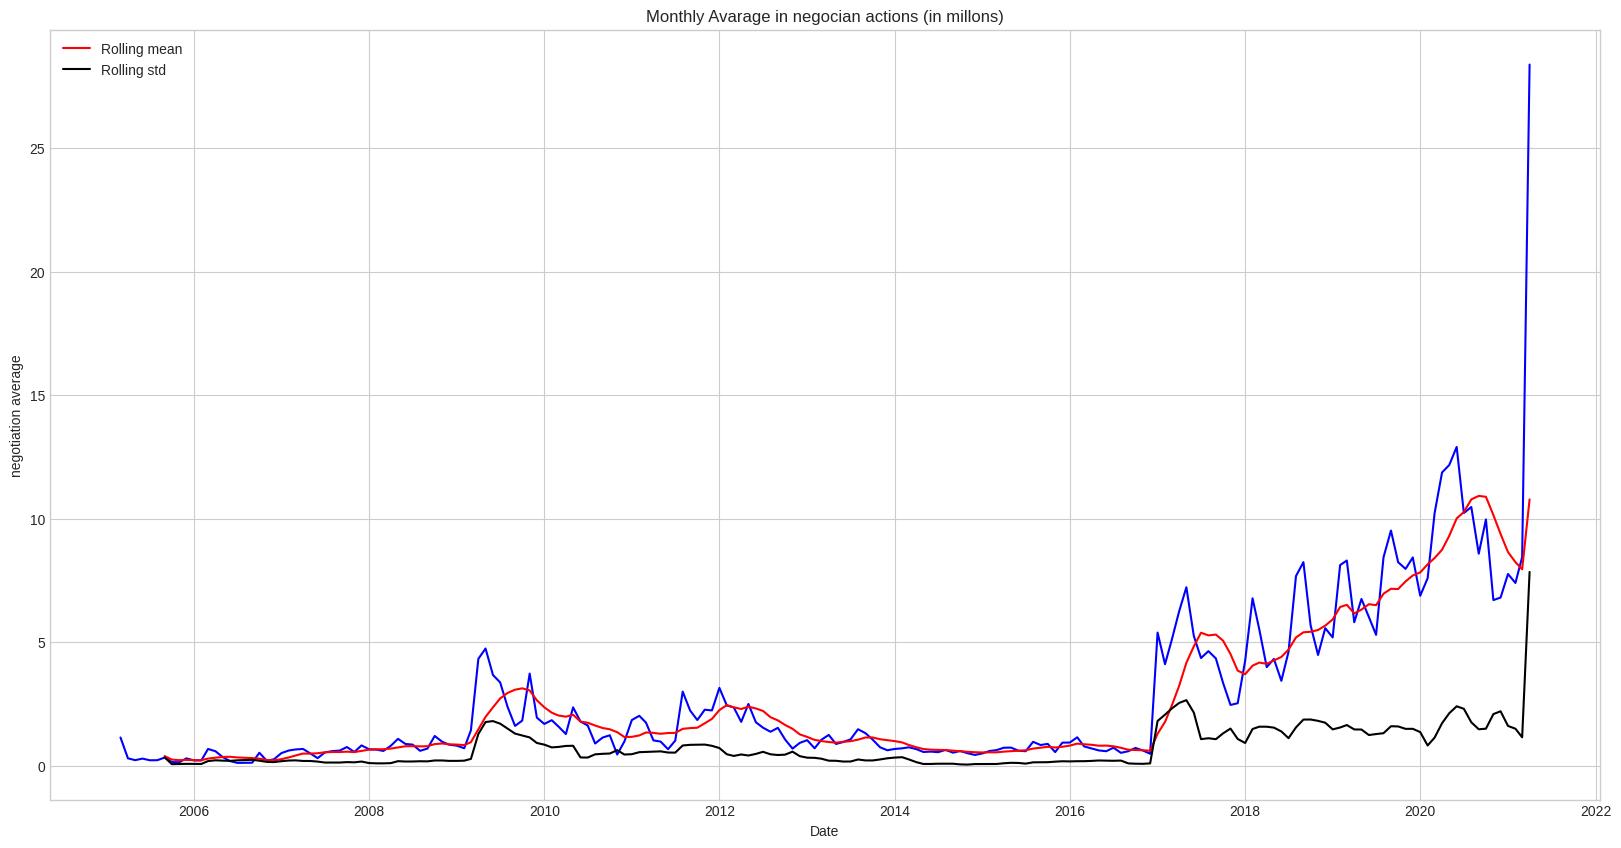

,Volume_Mill
count,194.000000
mean,2.697658
std,3.447382
min,0.113169
25%,0.618897
50%,1.057543
75%,4.077056
max,28.378956


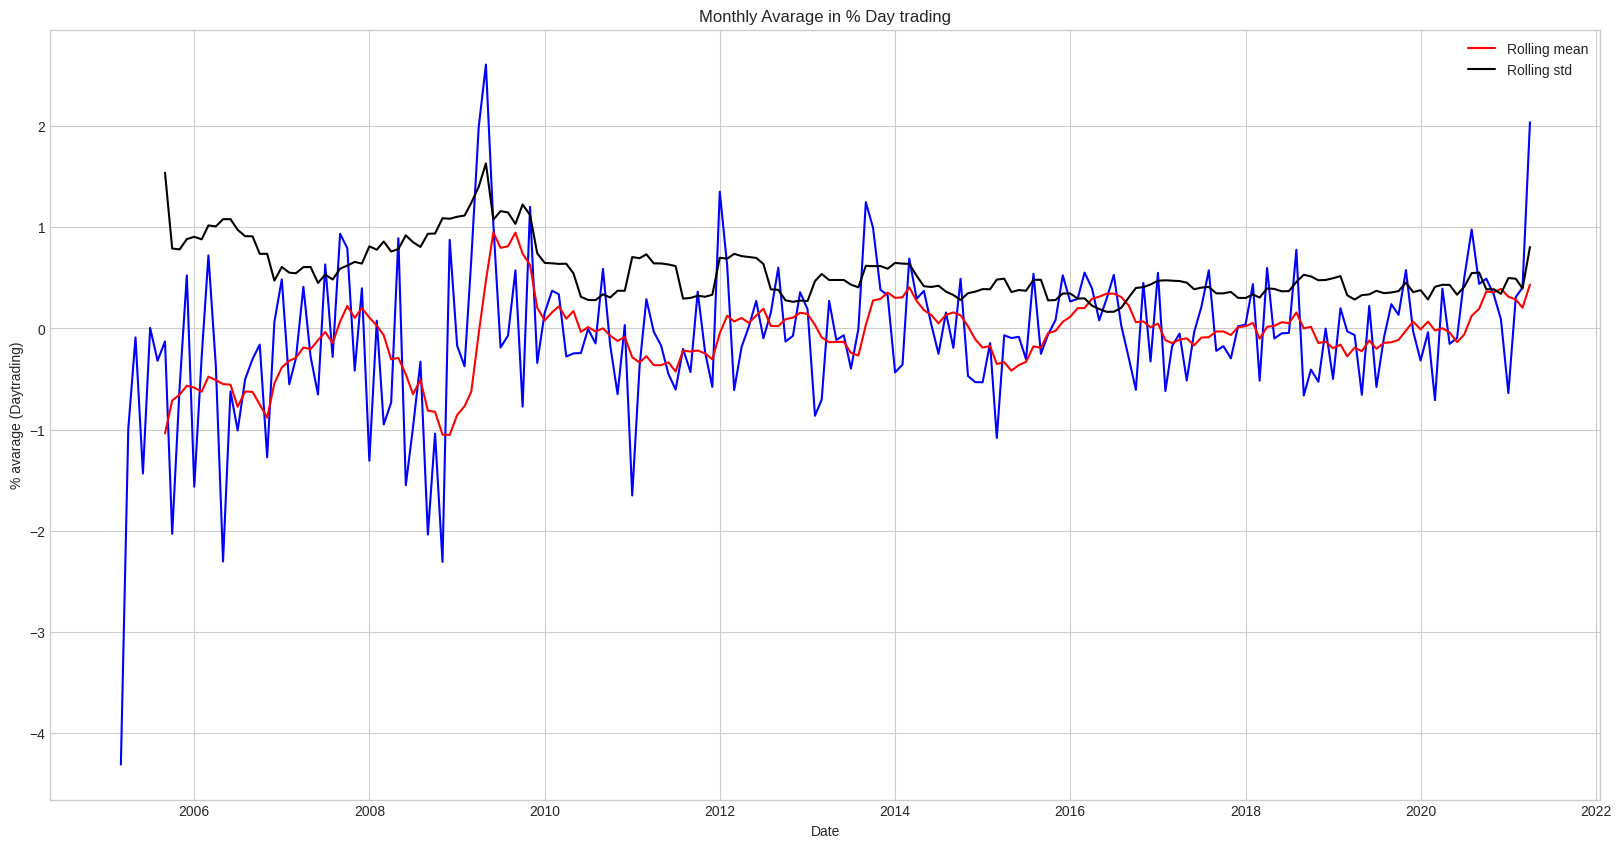

,%_DayTrading
count,194.000000
mean,-0.091099
std,0.740327
min,-4.309703
25%,-0.405182
50%,-0.079578
75%,0.335599
max,2.605537


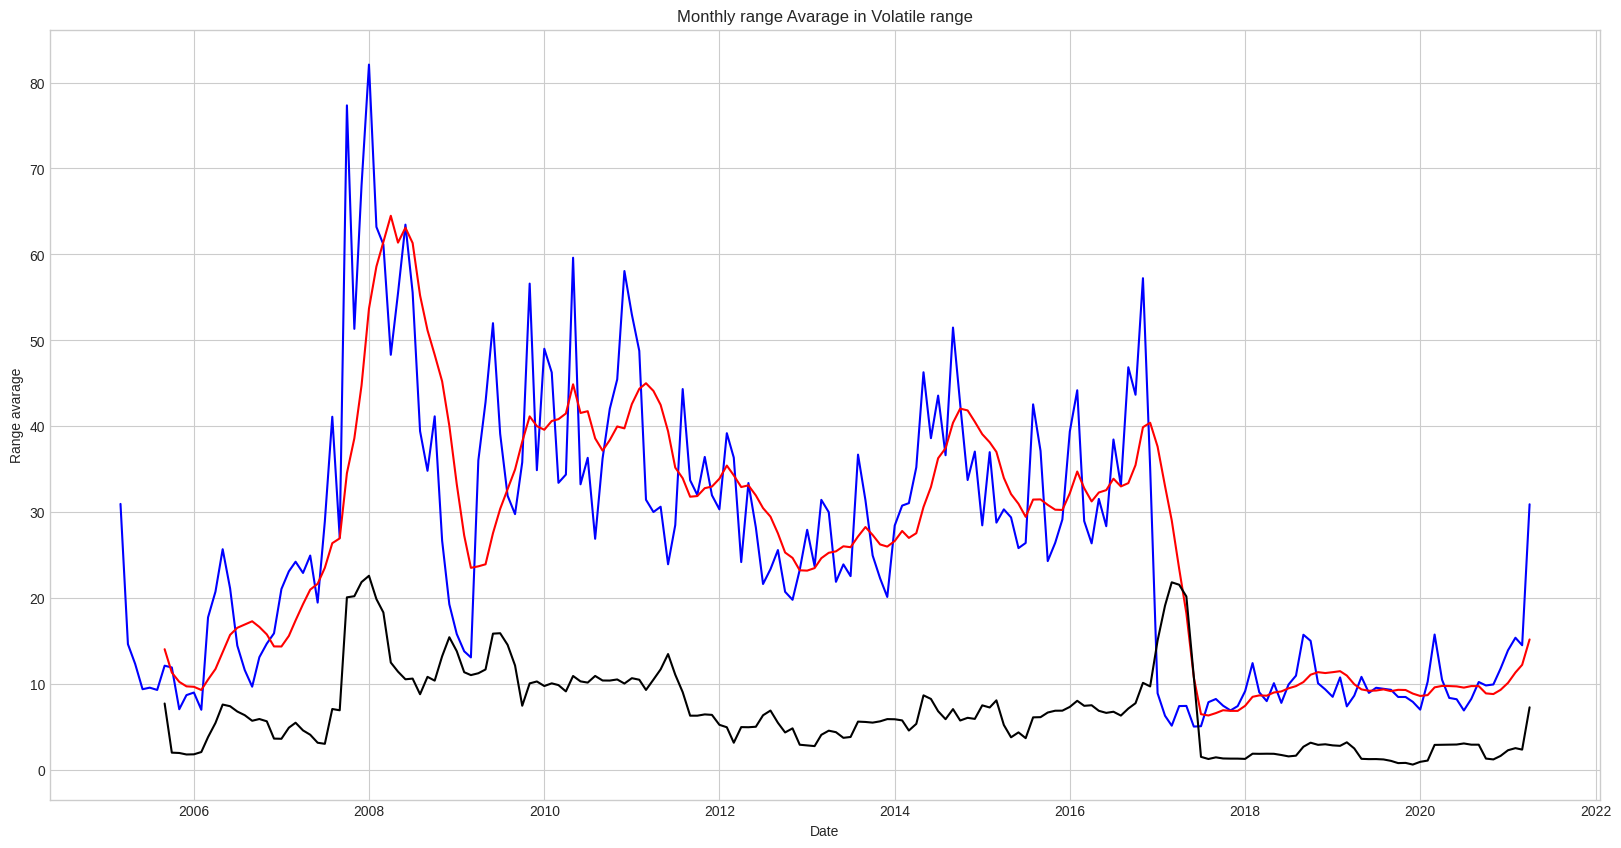

,Volatile_range
count,194.000000
mean,26.189785
std,15.877141
min,5.030952
25%,10.768920
50%,25.627386
75%,35.965441
max,82.089130


In [6]:
Date = df['Date']
Date= pd.to_datetime(Date)

#Group→ Year-Month

df['Year-Month'] = Date.dt.to_period('M')


#1. Month avarage in Close price

Monthly_close = df.groupby('Year-Month')['Close'].mean()
Monthly_close.index = Monthly_close.index.to_timestamp()
Close_mean = Monthly_close.rolling(window= 7).mean()  #movil mean
Close_std = Monthly_close.rolling(window= 7).std() #movil std


plt.figure(figsize=(20,10))
plt.plot(Monthly_close.index, Monthly_close.values, color= 'blue')
plt.plot(Close_mean, color= 'red', label = 'Rolling mean')
plt.plot(Close_std, color= 'black', label = 'Rolling std')
plt.title('Monthly Avarage in close price')
plt.xlabel('Date')
plt.ylabel('Price avarage (close)')
plt.legend()
plt.show()
display(Monthly_close.describe())



#2. Month avarage in Intraday_change.
Monthly_Interday = df.groupby('Year-Month')['Intraday_change'].mean()
Monthly_Interday.index = Monthly_Interday.index.to_timestamp()
Interday_mean = Monthly_Interday.rolling(window= 7).mean()
Interday_std = Monthly_Interday.rolling(window= 7).std()

plt.figure(figsize=(20,10))
plt.plot(Monthly_Interday.index, Monthly_Interday.values, color= 'blue')
plt.plot(Interday_mean, color= 'red', label = 'Rolling mean')
plt.plot(Interday_std, color= 'black', label = 'Rolling std')
plt.title('Monthly Avarage in Interday change')
plt.xlabel('Date')
plt.ylabel('Price avarage (high)')
plt.legend()
plt.show()
display(Monthly_Interday.describe())


#3. Month avarage in volume.

Monthly_volumemill = df.groupby('Year-Month')['Volume_Mill'].mean()
Monthly_volumemill.index = Monthly_volumemill.index.to_timestamp()
Volume_mean = Monthly_volumemill.rolling(window= 7).mean()
Volume_std = Monthly_volumemill.rolling(window= 7).std()

plt.figure(figsize=(20,10))
plt.plot(Monthly_volumemill.index, Monthly_volumemill.values, color = 'blue')
plt.plot(Volume_mean, color= 'red', label = 'Rolling mean')
plt.plot(Volume_std, color= 'black', label = 'Rolling std')
plt.title('Monthly Avarage in negocian actions (in millons)')
plt.xlabel('Date')
plt.ylabel('negotiation average')
plt.legend()
plt.show()
display(Monthly_volumemill.describe())



#4. Month avarage in %_DayTrading.

Monthly_DayTrading = df.groupby('Year-Month')['%_DayTrading'].mean()
Monthly_DayTrading.index = Monthly_DayTrading.index.to_timestamp()
DayTrading_mean = Monthly_DayTrading.rolling(window= 7).mean()
DayTrading_std = Monthly_DayTrading.rolling(window= 7).std()

plt.figure(figsize=(20,10))
plt.plot(Monthly_DayTrading.index, Monthly_DayTrading.values, color = 'blue')
plt.plot(DayTrading_mean, color= 'red', label = 'Rolling mean')
plt.plot(DayTrading_std, color= 'black', label = 'Rolling std')
plt.title('Monthly Avarage in % Day trading')
plt.xlabel('Date')
plt.ylabel('% avarage (Daytrading)')
plt.legend()
plt.show()
display(Monthly_DayTrading.describe())



#5. Month avarage in Volatile range.

Monthly_VolatileRange = df.groupby('Year-Month')['Volatile_range'].mean()
Monthly_VolatileRange.index = Monthly_VolatileRange.index.to_timestamp()
VolatileRange_mean = Monthly_VolatileRange.rolling(window= 7).mean()
VolatileRange_std = Monthly_VolatileRange.rolling(window= 7).std()

plt.figure(figsize=(20,10))
plt.plot(Monthly_VolatileRange.index, Monthly_VolatileRange.values, color = 'blue')
plt.plot(VolatileRange_mean, color= 'red', label = 'Rolling mean')
plt.plot(VolatileRange_std, color= 'black', label = 'Rolling std')
plt.title('Monthly range Avarage in Volatile range')
plt.xlabel('Date')
plt.ylabel('Range avarage')
plt.show()
display(Monthly_VolatileRange.describe())

# 2.Aplique el test ADF con tres especificaciones:

  2.1 Sin constante ni tendencia (regression='n')  
  2.2 Con constante (regression='c')  
  2.3 Con constante y tendencia (regression='ct')  
  2.4 Compare los resultados y discuta cuál especificación es más apropiada y por qué.


Verificar si las series son estacionarias chequeando el p_value..

 * valor < 0.05 (la serie es estacionaria).--> no hay suficiente evidencia para afirmar tu hipotesis.

 * valor > 0.05 (la serie NO es estacionaria)--> hay suficiente evidencia para afirmar tu hipotesis.


H0) 'La serie no es estacionaria'.

H1) 'La serie es estacionaria '.

In [7]:
Monthly_close = df['Close']
Monthly_Interday = df['Intraday_change']
Monthly_volume = df['Volume_Mill']
Monthly_DayTrading = df['%_DayTrading']
Monthly_VolatileRange = df['Volatile_range']


**Prueba Adfuller.**

Hipótesis:

H₀ (nula): la serie NO ES estacionaria

H₁ (alternativa): la serie ES es estacionaria

Interpretación:

p-value < 0.05 → rechazas H₀ →  es estacionaria ✅

p-value > 0.05 → no rechazó H₀ →  no estacionaria ❌


In [8]:
def check_stationarityCLS(serie1, Monthly_close):
  print(f'1. Checking stationarity for {Monthly_close}...')
  result = adfuller(serie1.dropna())

  p_value = result[1]
  adf_statistic = result[0]

  print(f'ADF Statistic: {adf_statistic:.4f}')
  print(f'p-value: {p_value:.4f}')

  # Interpretación
  if p_value <= 0.05:
    print(f"Conclusion: the serie is stationarity (discard H0), becouse p-value ({p_value:.4f}) is <= 0.05.")
  else:
    print(f"Conclusion: the serie isn't stationarity (accert H0), becouse p-value ({p_value:.4f}) is > 0.05.")
  print("-" * 50)


check_stationarityCLS(Monthly_close, 'Monthly_close')


def check_stationarityINTD(serie2, Monthly_Interday):
  print(f'2. Checking stationarity for {Monthly_Interday}...')
  result = adfuller(serie2.dropna())

  p_value = result[1]
  adf_statistic = result[0]

  print(f'ADF Statistic: {adf_statistic:.4f}')
  print(f'p-value: {p_value:.4f}')

  # Interpret the p-value based on the provided hypothesis
  if p_value <= 0.05:
    print(f"Conclusion: the serie is stationarity (discard H0), becouse p-value ({p_value:.4f}) is <= 0.05.")
  else:
    print(f"Conclusion: the serie isn't stationarity (accert H0), becouse p-value ({p_value:.4f}) is > 0.05.")
  print("-" * 50)


check_stationarityINTD(Monthly_Interday, 'Monthly_interday')


def check_stationarityVOL(serie3, Monthly_volume):
  print(f'3. Checking stationarity for {Monthly_volume}')
  result = adfuller(serie3.dropna())

  p_value = result[1]
  adf_statistic = result[0]

  print(f'ADF Statistic: {adf_statistic:.4f}')
  print(f'p-value: {p_value:.4f}')

  # Interpret the p-value based on the provided hypothesis
  if p_value <= 0.05:
    print(f"Conclusion: the serie is stationarity (discard H0), becouse p-value ({p_value:.4f}) is <= 0.05.")
  else:
    print(f"Conclusion: the serie isn't stationarity (accert H0), becouse p-value ({p_value:.4f}) is > 0.05.")
  print("-" * 50)


check_stationarityVOL(Monthly_volume, 'Monthly_volume')


def check_stationarityTRD(serie4, Monthly_DayTrading):
  print(f'3. Checking stationarity for {Monthly_DayTrading}')
  result = adfuller(serie4.dropna())

  p_value = result[1]
  adf_statistic = result[0]

  print(f'ADF Statistic: {adf_statistic:.4f}')
  print(f'p-value: {p_value:.4f}')

  # Interpret the p-value based on the provided hypothesis
  if p_value <= 0.05:
    print(f"Conclusion: the serie is stationarity (discard H0), becouse p-value ({p_value:.4f}) is <= 0.05.")
  else:
    print(f"Conclusion: the serie isn't stationarity (accert H0), becouse p-value ({p_value:.4f}) is > 0.05.")
  print("-" * 50)


check_stationarityTRD(Monthly_DayTrading, 'Monthly_DayTrading')


def check_stationarityVOLR(serie5, Monthly_VolatileRange):
  print(f'3. Checking stationarity for {Monthly_VolatileRange}')
  result = adfuller(serie5.dropna())

  p_value = result[1]
  adf_statistic = result[0]

  print(f'ADF Statistic: {adf_statistic:.4f}')
  print(f'p-value: {p_value:.4f}')

  # Interpret the p-value based on the provided hypothesis
  if p_value <= 0.05:
    print(f"Conclusion: the serie is stationarity (discard H0), becouse p-value ({p_value:.4f}) is <= 0.05.")
  else:
    print(f"Conclusion: the serie isn't stationarity (accert H0), becouse p-value ({p_value:.4f}) is > 0.05.")
  print("-" * 50)


check_stationarityVOLR(Monthly_VolatileRange, 'Monthly_VolatileRange')



1. Checking stationarity for Monthly_close...
ADF Statistic: -2.5075
p-value: 0.1137
Conclusion: the serie isn't stationarity (accert H0), becouse p-value (0.1137) is > 0.05.
--------------------------------------------------
2. Checking stationarity for Monthly_interday...
ADF Statistic: -15.8668
p-value: 0.0000
Conclusion: the serie is stationarity (discard H0), becouse p-value (0.0000) is <= 0.05.
--------------------------------------------------
3. Checking stationarity for Monthly_volume
ADF Statistic: 0.7492
p-value: 0.9908
Conclusion: the serie isn't stationarity (accert H0), becouse p-value (0.9908) is > 0.05.
--------------------------------------------------
3. Checking stationarity for Monthly_DayTrading
ADF Statistic: -63.3723
p-value: 0.0000
Conclusion: the serie is stationarity (discard H0), becouse p-value (0.0000) is <= 0.05.
--------------------------------------------------
3. Checking stationarity for Monthly_VolatileRange
ADF Statistic: -3.9557
p-value: 0.0017
Conc

explicar: **Interpretaciones sobre lo observado en los graficos:**





# 3. Si la serie no es estacionaria, determine el orden de integración I(d):  
  

Checking stationarity differenced 'Close' price...
ADF Statistic: -22.1257
p-value: 0.0000
Conclusion: The series is stationary (discard H0), because p-value (0.0000) is <= 0.05.
--------------------------------------------------


,Close
1,-20.95
2,9.65
3,-10.80
4,-5.90
5,0.35
...,...
3989,20.40
3990,10.10
3991,-3.25
3992,63.85


,Close
count,3993.000000
mean,0.082069
std,30.801548
min,-1481.500000
25%,-7.250000
50%,0.300000
75%,8.150000
max,117.150000


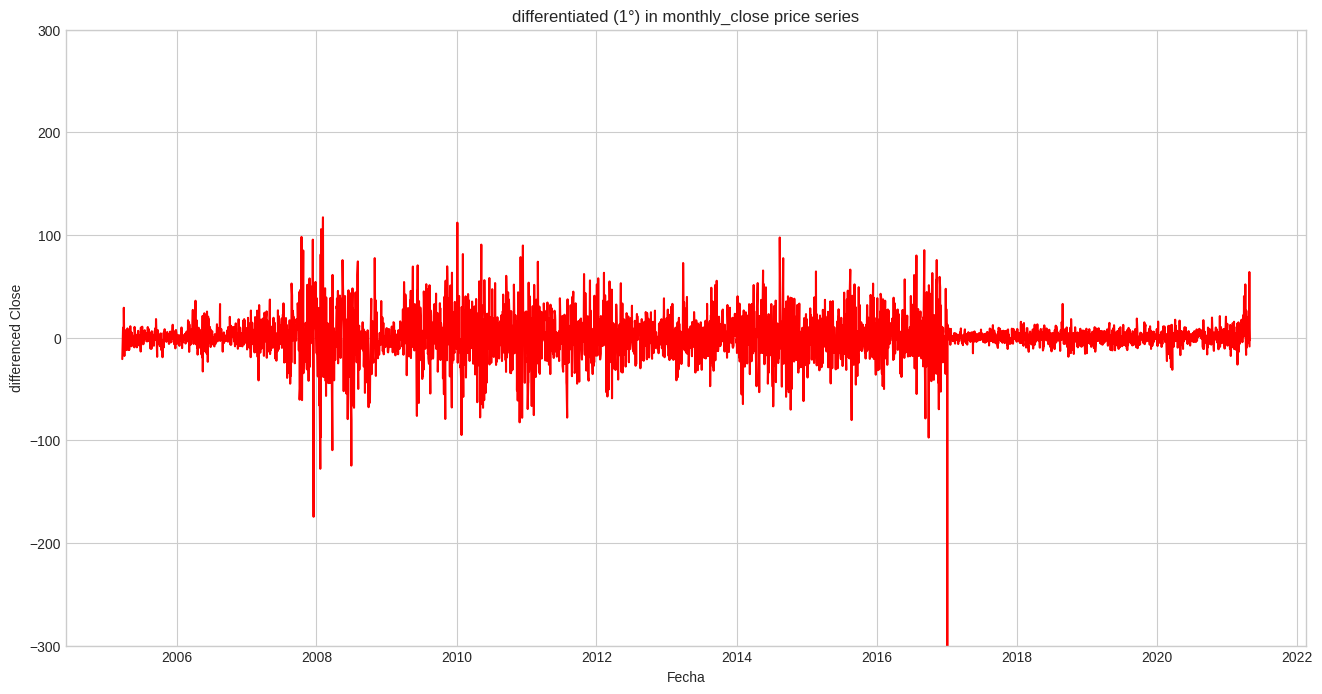

Checking stationarity differenced 'Volume' negocian series...
ADF Statistic: -11.0964
p-value: 3.964e-20
Conclusion: The series is stationary (discard H0), because p-value (0.0000) is <= 0.05.
--------------------------------------------------


,Volume_Mill
1,-0.861231
2,0.009315
3,-0.611722
4,-0.157723
5,0.736666
...,...
3989,-1.424556
3990,-0.707080
3991,-0.240509
3992,41.258013


,Volume_Mill
count,3993.000000
mean,0.008606
std,2.437183
min,-24.015075
25%,-0.347051
50%,-0.015618
75%,0.296436
max,51.981445


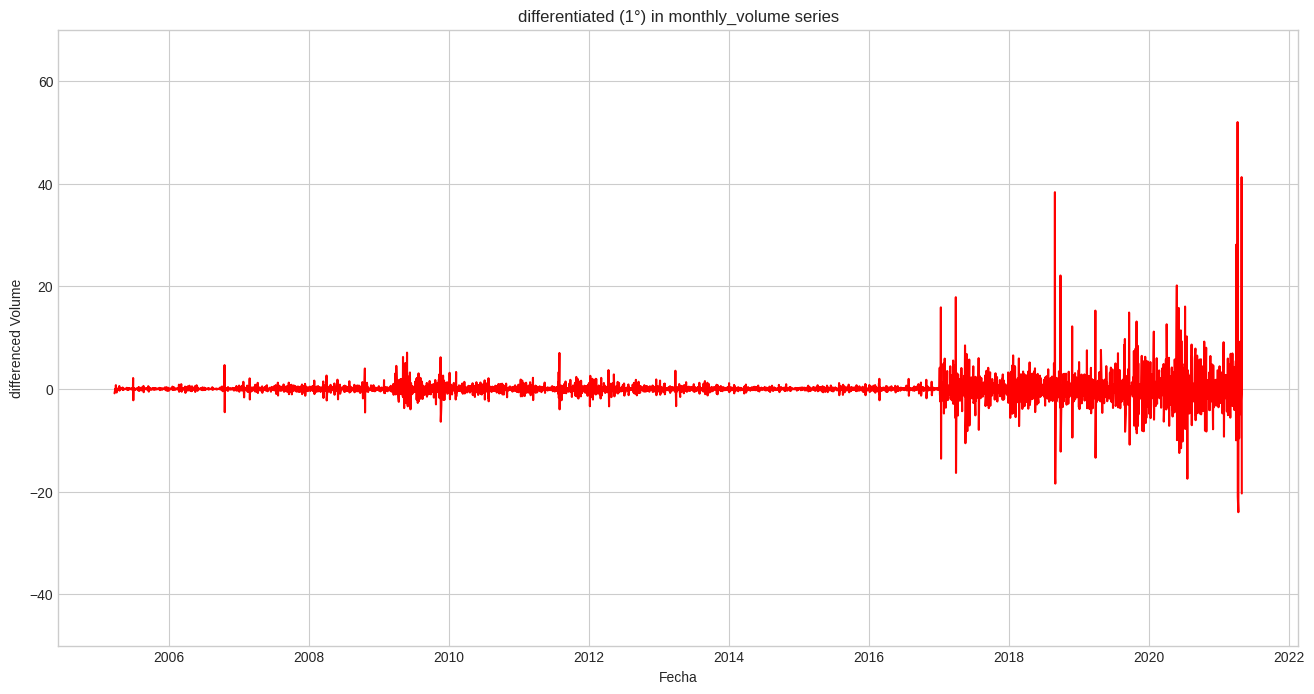

In [9]:
#1ra serie no estac→ 'monthly_close'

diff_close = Monthly_close.diff().dropna(axis=False)
result = adfuller(diff_close.dropna(), regression='c')

p_value = result[1]
adf_statistic = result[0]

print(f"Checking stationarity differenced 'Close' price...")
print(f'ADF Statistic: {adf_statistic:.4f}')
print(f'p-value: {p_value:.4f}')

# Interpretación
if p_value <= 0.05:
  print(f"Conclusion: The series is stationary (discard H0), because p-value ({p_value:.4f}) is <= 0.05.")
else:
  print(f"Conclusion: The series is not stationary (accept H0), because p-value ({p_value:.4f}) is > 0.05.")
print("-" * 50)

#en 'monthly_close' tuvimos que aplicar solo una diferenciación para convertirla en estacionaria.

plt.figure(figsize=(16,8))
plt.plot(Date.iloc[1:], diff_close, color = 'red')
plt.ylim(-300, 300)
plt.title("differentiated (1°) in monthly_close price series")
plt.xlabel("Fecha")
plt.ylabel("differenced Close")

display(diff_close)
display(diff_close.describe())
plt.show()

#Ahora si aplicamos una diferenciación de un grado, la media movil se mantiene constante entre -200 y 110. Hay un outlier, registrado en 2016

#2da serie no estac→ 'Monthly_volume'

diff_volume = Monthly_volume.diff().dropna(axis=False)
result = adfuller(diff_volume.dropna(), regression='c')

p_value = result[1]
adf_statistic = result[0]

print(f"Checking stationarity differenced 'Volume' negocian series...")
print(f'ADF Statistic: {adf_statistic:.4f}')
print(f'p-value: {p_value:.4}')

#Interpretación

if p_value <= 0.05:
  print(f"Conclusion: The series is stationary (discard H0), because p-value ({p_value:.4f}) is <= 0.05.")
else:
    print(f"Conclusion: The series is not stationary (accept H0), because p-value ({p_value:.4f}) is > 0.05.")
print("-" * 50)

plt.figure(figsize=(16,8))
plt.plot(Date.iloc[1:], diff_volume, color='red')
plt.ylim(-50,70)
plt.title("differentiated (1°) in monthly_volume series")
plt.xlabel("Fecha")
plt.ylabel("differenced Volume")

display(diff_volume)
display(diff_volume.describe())
plt.show()




# 4.  Grafique la ACF de la serie original y de la serie diferenciada. ¿Qué diferencias observa? ¿Cómo se relaciona esto con la estacionariedad?

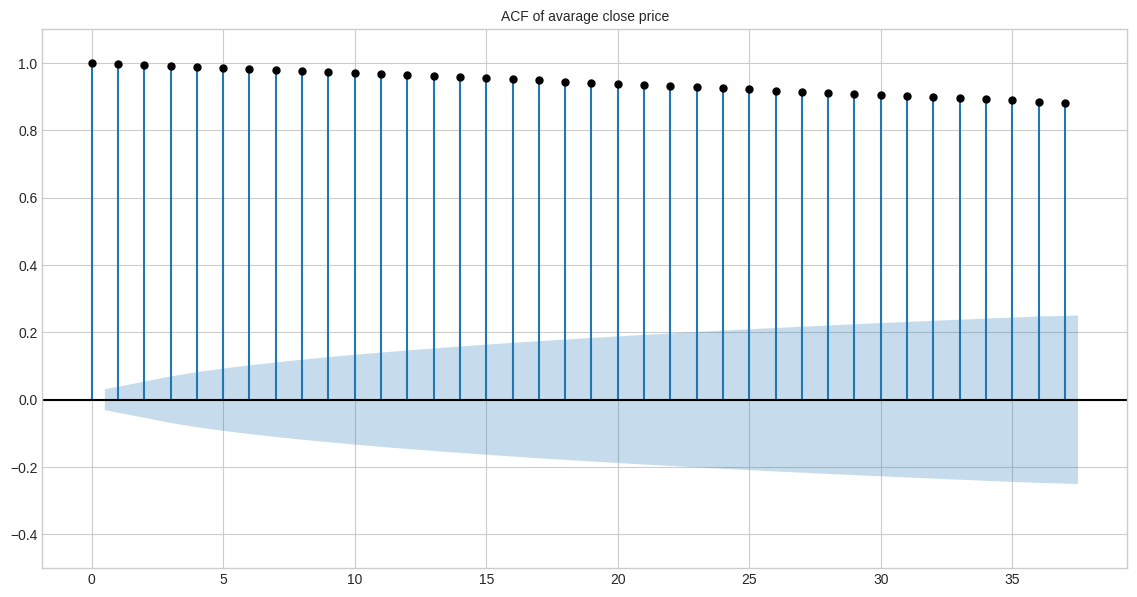

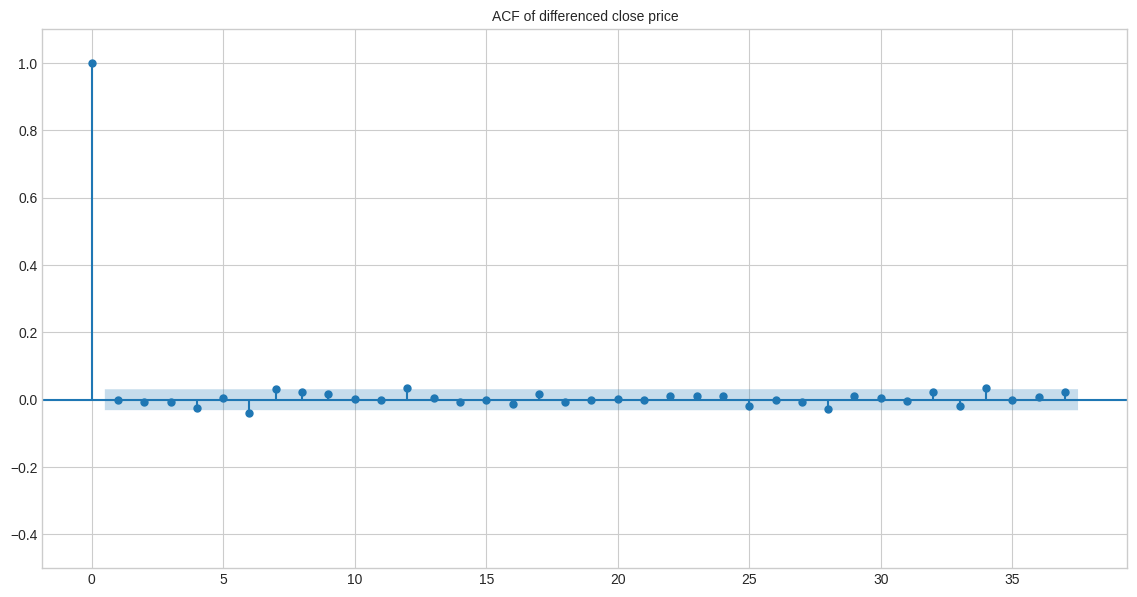

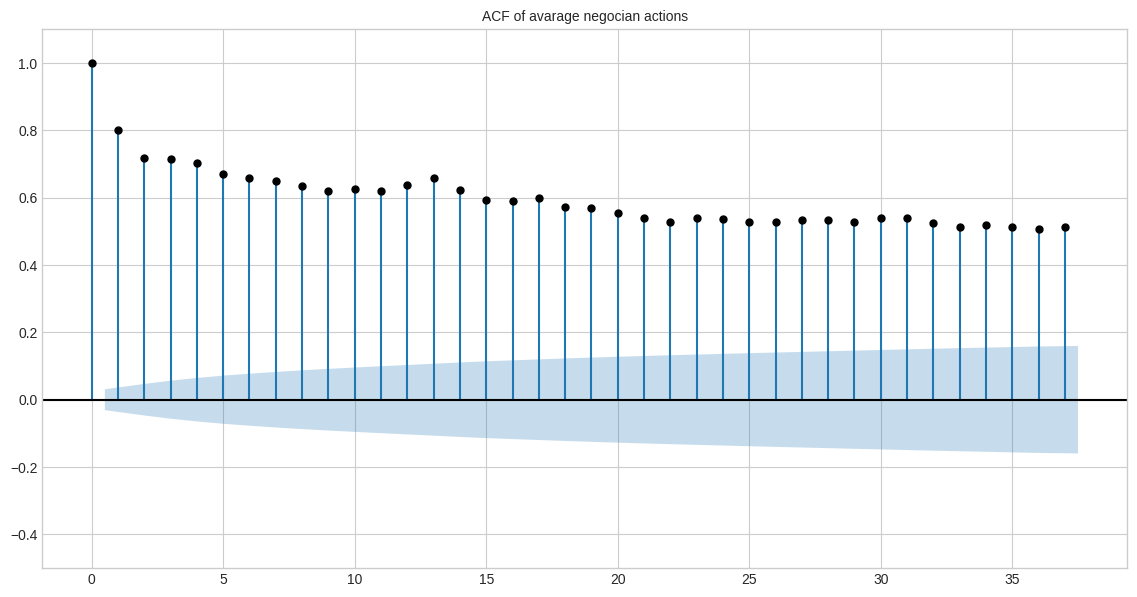

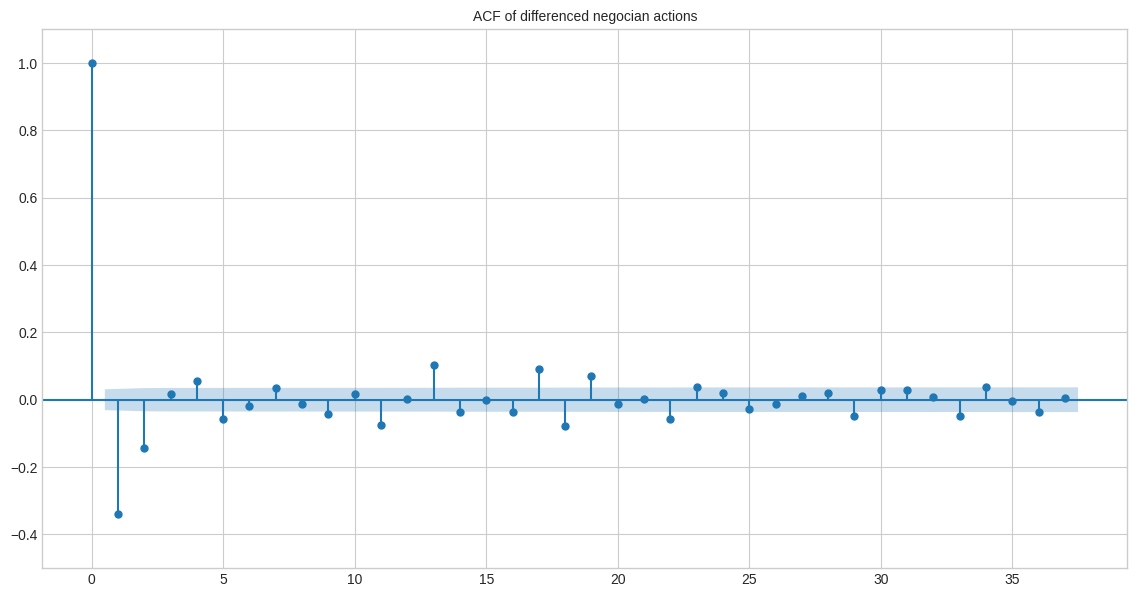

In [10]:
#1a) Serie → 'Monthly_close' sin estacionariedad.


fig, ax = plt.subplots(figsize=(14,7))
plot_acf(Monthly_close, color = 'black', ax= ax)
plt.ylim(-0.5, 1.1)
plt.title('ACF of avarage close price', fontsize=10)
plt.show()

#1b) Serie → 'diff_close' estacionaria.

fig, ax = plt.subplots(figsize=(14,7))
plot_acf(diff_close, ax=ax)
plt.ylim(-0.5, 1.1)
plt.title('ACF of differenced close price', fontsize=10)
plt.show()


#2a) Serie → 'Monthly_volume' sin estacionariedad.

fig, size = plt.subplots(figsize=(14,7))
plot_acf(Monthly_volume, color = 'black', ax=size)
plt.ylim(-0.5, 1.1)
plt.title('ACF of avarage negocian actions', fontsize=10)
plt.show()

#2b) Serie → 'diff_volume' estacionaria.

fig, size = plt.subplots(figsize=(14,7))
plot_acf(diff_volume, ax=size)
plt.ylim(-0.5, 1.1)
plt.title('ACF of differenced negocian actions', fontsize=10)
plt.show()

# Parte 2 → Prueba Kpss y modelos ARMA.
Fecha: 6/5/26

**Regla (Kpss) en volumen de negociaciones.**

* H₀ (nula): la serie ES estacionaria
* H₁ (alternativa): la serie NO es estacionaria

p-value < 0.05 → rechazas H₀ → ❌ no estacionaria

p-value > 0.05 → no rechazó H₀ → ✅ estacionaria


In [11]:
#Prueba Kpss

print('--Prueba Kpss en serie original---')

kpss_original = kpss(Monthly_volume.dropna(), regression = 'c', nlags= 'auto')
print(f'Estadistico de prueba: {kpss_original[0]:.4f}')
print(f'P_value: {kpss_original[1]:.4f}')
print(f'valores criticos: {kpss_original[3]}')

if kpss_original[1] <= 0.05:
  print(f'Conclusion: The original series isnt stationaity(discard H0)')

else:
    print(f'Conclusion: The original series is stationaity(accept H0)')

print("--"*50)


kpss_diff = kpss(diff_volume.dropna(), regression = 'c', nlags= 'auto')
print('--Prueba Kpss en serie diferenciada---')
print(f'Estadistico de prueba: {kpss_diff[0]:.4f}')
print(f'P_value: {kpss_diff[1]:.4f}')
print(f'valores criticos: {kpss_diff[3]}')

if kpss_diff[1] <= 0.05:
  print(f'Conclusion: The series isnt stationaity(discard H0)')

else:
    print(f'Conclusion: The series is stationaity(accept H0)')

--Prueba Kpss en serie original---
Estadistico de prueba: 5.5210
P_value: 0.0100
valores criticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Conclusion: The original series isnt stationaity(discard H0)
----------------------------------------------------------------------------------------------------
--Prueba Kpss en serie diferenciada---
Estadistico de prueba: 0.3972
P_value: 0.0784
valores criticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Conclusion: The series is stationaity(accept H0)


/tmp/ipykernel_3011/2008493271.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_original = kpss(Monthly_volume.dropna(), regression = 'c', nlags= 'auto')


In [12]:
print("--- TEMA 6: SELECCIÓN DE MODELO ARMA (CRITERIOS AIC/BIC) ---\n")

resultados = []
# Probamos órdenes de p y q desde 0 hasta 3
p_valores = range(0, 4)
q_valores = range(0, 4)

print("Ajustando modelos, por favor espera...\n")

for p in p_valores:
    for q in q_valores:
        if p == 0 and q == 0:
            continue # Omitimos el modelo sin AR ni MA (Ruido Blanco puro)

        try:
            # CORRECCIÓN: Usamos 'Diff_volume'
            modelo = ARIMA(diff_volume, order=(p, 0, q))
            ajuste = modelo.fit()

            # Guardamos los criterios de información
            resultados.append({
                'Modelo': f'ARMA({p},{q})',
                'p': p,
                'q': q,
                'AIC': ajuste.aic,
                'BIC': ajuste.bic
            })
        except:
            # Si un modelo no converge, lo omitimos
            continue

# Convertir a DataFrame y ordenar por AIC
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='AIC').reset_index(drop=True)

print("--- Ranking de Modelos según Criterios de Información ---")
print(df_resultados.head(10))

# Extraemos los mejores hiperparámetros automáticamente
mejor_modelo = df_resultados.iloc[0]
mejor_p = int(mejor_modelo['p'])
mejor_q = int(mejor_modelo['q'])

print("-" * 50)
print(f"El modelo sugerido como ganador es el {mejor_modelo['Modelo']}")
print(f"AIC: {mejor_modelo['AIC']:.2f} | BIC: {mejor_modelo['BIC']:.2f}")

--- TEMA 6: SELECCIÓN DE MODELO ARMA (CRITERIOS AIC/BIC) ---

Ajustando modelos, por favor espera...



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

--- Ranking de Modelos según Criterios de Información ---
      Modelo  p  q           AIC           BIC
0  ARMA(3,3)  3  3  17224.458451  17274.796836
1  ARMA(3,2)  3  2  17231.977635  17276.023722
2  ARMA(3,1)  3  1  17233.080884  17270.834672
3  ARMA(2,3)  2  3  17243.634244  17287.680330
4  ARMA(1,1)  1  1  17261.228571  17286.397764
5  ARMA(1,2)  1  2  17262.301044  17293.762535
6  ARMA(2,1)  2  1  17262.895889  17294.357379
7  ARMA(2,2)  2  2  17264.210252  17301.964040
8  ARMA(0,3)  0  3  17273.045481  17304.506972
9  ARMA(1,3)  1  3  17277.838432  17315.592221
--------------------------------------------------
El modelo sugerido como ganador es el ARMA(3,3)
AIC: 17224.46 | BIC: 17274.80


In [13]:
#Medidas de presición.



In [14]:
#Validación teorica del mejor modelo

print(f"Mejor modelo: {mejor_modelo['Modelo']}")

# 1. Ajustamos el modelo ganador de forma definitiva

modelo_ganador = ARIMA(diff_volume, order=(mejor_p, 0, mejor_q))
ajuste_final = modelo_ganador.fit()

# 2. Extraemos los coeficientes
ar_coefs = ajuste_final.arparams
ma_coefs = ajuste_final.maparams

print("--- Coeficientes del modelo ---")
print(f"AR (phi): {ar_coefs}")
print(f"MA (theta): {ma_coefs}\n")

# 3. Extraemos las raíces de los polinomios y calculamos su módulo (valor absoluto)
ar_raices = ajuste_final.arroots
ma_raices = ajuste_final.maroots

print("--- Validación Teórica (El módulo debe ser > 1) ---")
if mejor_p > 0:
    print("Raíces del polinomio AR (Verifica Causalidad y Estabilidad):")
    for i, raiz in enumerate(ar_raices):
        print(f"  Raíz {i+1}: {raiz:.4f} | Módulo: {np.abs(raiz):.4f}")

if mejor_q > 0:
    print("\nRaíces del polinomio MA (Verifica Invertibilidad):")
    for i, raiz in enumerate(ma_raices):
        print(f"  Raíz {i+1}: {raiz:.4f} | Módulo: {np.abs(raiz):.4f}")

Mejor modelo: ARMA(3,3)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


--- Coeficientes del modelo ---
AR (phi): [-0.20456991 -0.73750784  0.34231173]
MA (theta): [-0.34484426  0.40778509 -0.80811256]

--- Validación Teórica (El módulo debe ser > 1) ---
Raíces del polinomio AR (Verifica Causalidad y Estabilidad):
  Raíz 1: -0.3007-0.9847j | Módulo: 1.0296
  Raíz 2: -0.3007+0.9847j | Módulo: 1.0296
  Raíz 3: 2.7560-0.0000j | Módulo: 2.7560

Raíces del polinomio MA (Verifica Invertibilidad):
  Raíz 1: -0.3057-1.0077j | Módulo: 1.0530
  Raíz 2: -0.3057+1.0077j | Módulo: 1.0530
  Raíz 3: 1.1159-0.0000j | Módulo: 1.1159


* Calculo de automodelado (predecir el futuro)

Consigna: predecir valor promedio de las features (price_close - price_Interday- volume-
%_DayTrading-
price_VolatileRange) en los proximos 150-200 dias (dependiendo la serie).



In [15]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_model import ARIMAResults

In [16]:
# 'Price closing'
lags = 5
model_close = AutoReg(Monthly_close, lags=lags, old_names=False)
model_fit_close = model_close.fit()

predictions_closing = model_fit_close.predict(start= len(Monthly_Interday) - 200, end=len(Monthly_Interday) + lags + 100)
print('Predicción→ Cierre de precio mensual estimado para los proximos 5 MESES: ')
print(predictions_closing)


#'Monthly Interday'
model_interday = AutoReg(Monthly_Interday, lags=lags, old_names=False)
model_fit_interday = model_interday.fit()

predictions_interday = model_fit_interday.predict(start= len(Monthly_Interday) -100, end=len(Monthly_Interday) + lags + 100)
print('Predicción→ Rango diario mensual de efectividad estimado para los proximos 5 MESES: ')
print(predictions_interday)

# 'Monthly_Volume'

model_volume = AutoReg(Monthly_volume, lags=lags, old_names=False)
model_fit_volume = model_volume.fit()

predictions_volume = model_fit_volume.predict(start= len(Monthly_volume) - 100, end=len(Monthly_volume) + lags + 100 )
print('Predicción→ Numero de negociaciones promedio estimadas para los proximos 5 MESES: ')
print(predictions_volume)

# ' %_DayTrading'

model_daytrading = AutoReg(Monthly_DayTrading, lags=lags, old_names=False)
model_fit_daytrading = model_daytrading.fit()

predictions_daytrading = model_fit_daytrading.predict(start= len(Monthly_DayTrading)-100, end=len(Monthly_DayTrading) + lags + 100)
print('Predicción→ Porcentaje estimado de efectividad (%) para los proximos 5 MESES: ')
print(predictions_daytrading)

# 'Monthly_volatilerange'

model_volatilerange = AutoReg(Monthly_VolatileRange, lags=lags, old_names=False)
model_fit_volatilerange = model_volatilerange.fit()

predictions_volatiler = model_fit_volatilerange.predict(start= len(Monthly_VolatileRange) -100, end=len(Monthly_VolatileRange) + lags + 100)
print('Predicción→ Rango frecuente estimado para los proximos 5 MESES: ')
print(predictions_volatiler)

Predicción→ Cierre de precio mensual estimado para los proximos 5 MESES: 
3794    199.799616
3795    195.490347
3796    196.477547
3797    202.542461
3798    208.269263
           ...    
4095    709.521498
4096    709.468209
4097    709.415074
4098    709.362095
4099    709.309269
Length: 306, dtype: float64
Predicción→ Rango diario mensual de efectividad estimado para los proximos 5 MESES: 
3894   -1.613966
3895    0.074987
3896   -1.105353
3897   -1.039164
3898   -0.374837
          ...   
4095   -0.626728
4096   -0.626728
4097   -0.626728
4098   -0.626728
4099   -0.626728
Length: 206, dtype: float64
Predicción→ Numero de negociaciones promedio estimadas para los proximos 5 MESES: 
3894    10.485322
3895     8.384111
3896     8.039059
3897     6.949819
3898     6.186863
          ...    
4095     4.204149
4096     4.165150
4097     4.127356
4098     4.090729
4099     4.055234
Length: 206, dtype: float64
Predicción→ Porcentaje estimado de efectividad (%) para los proximos 5 MESES: 
3

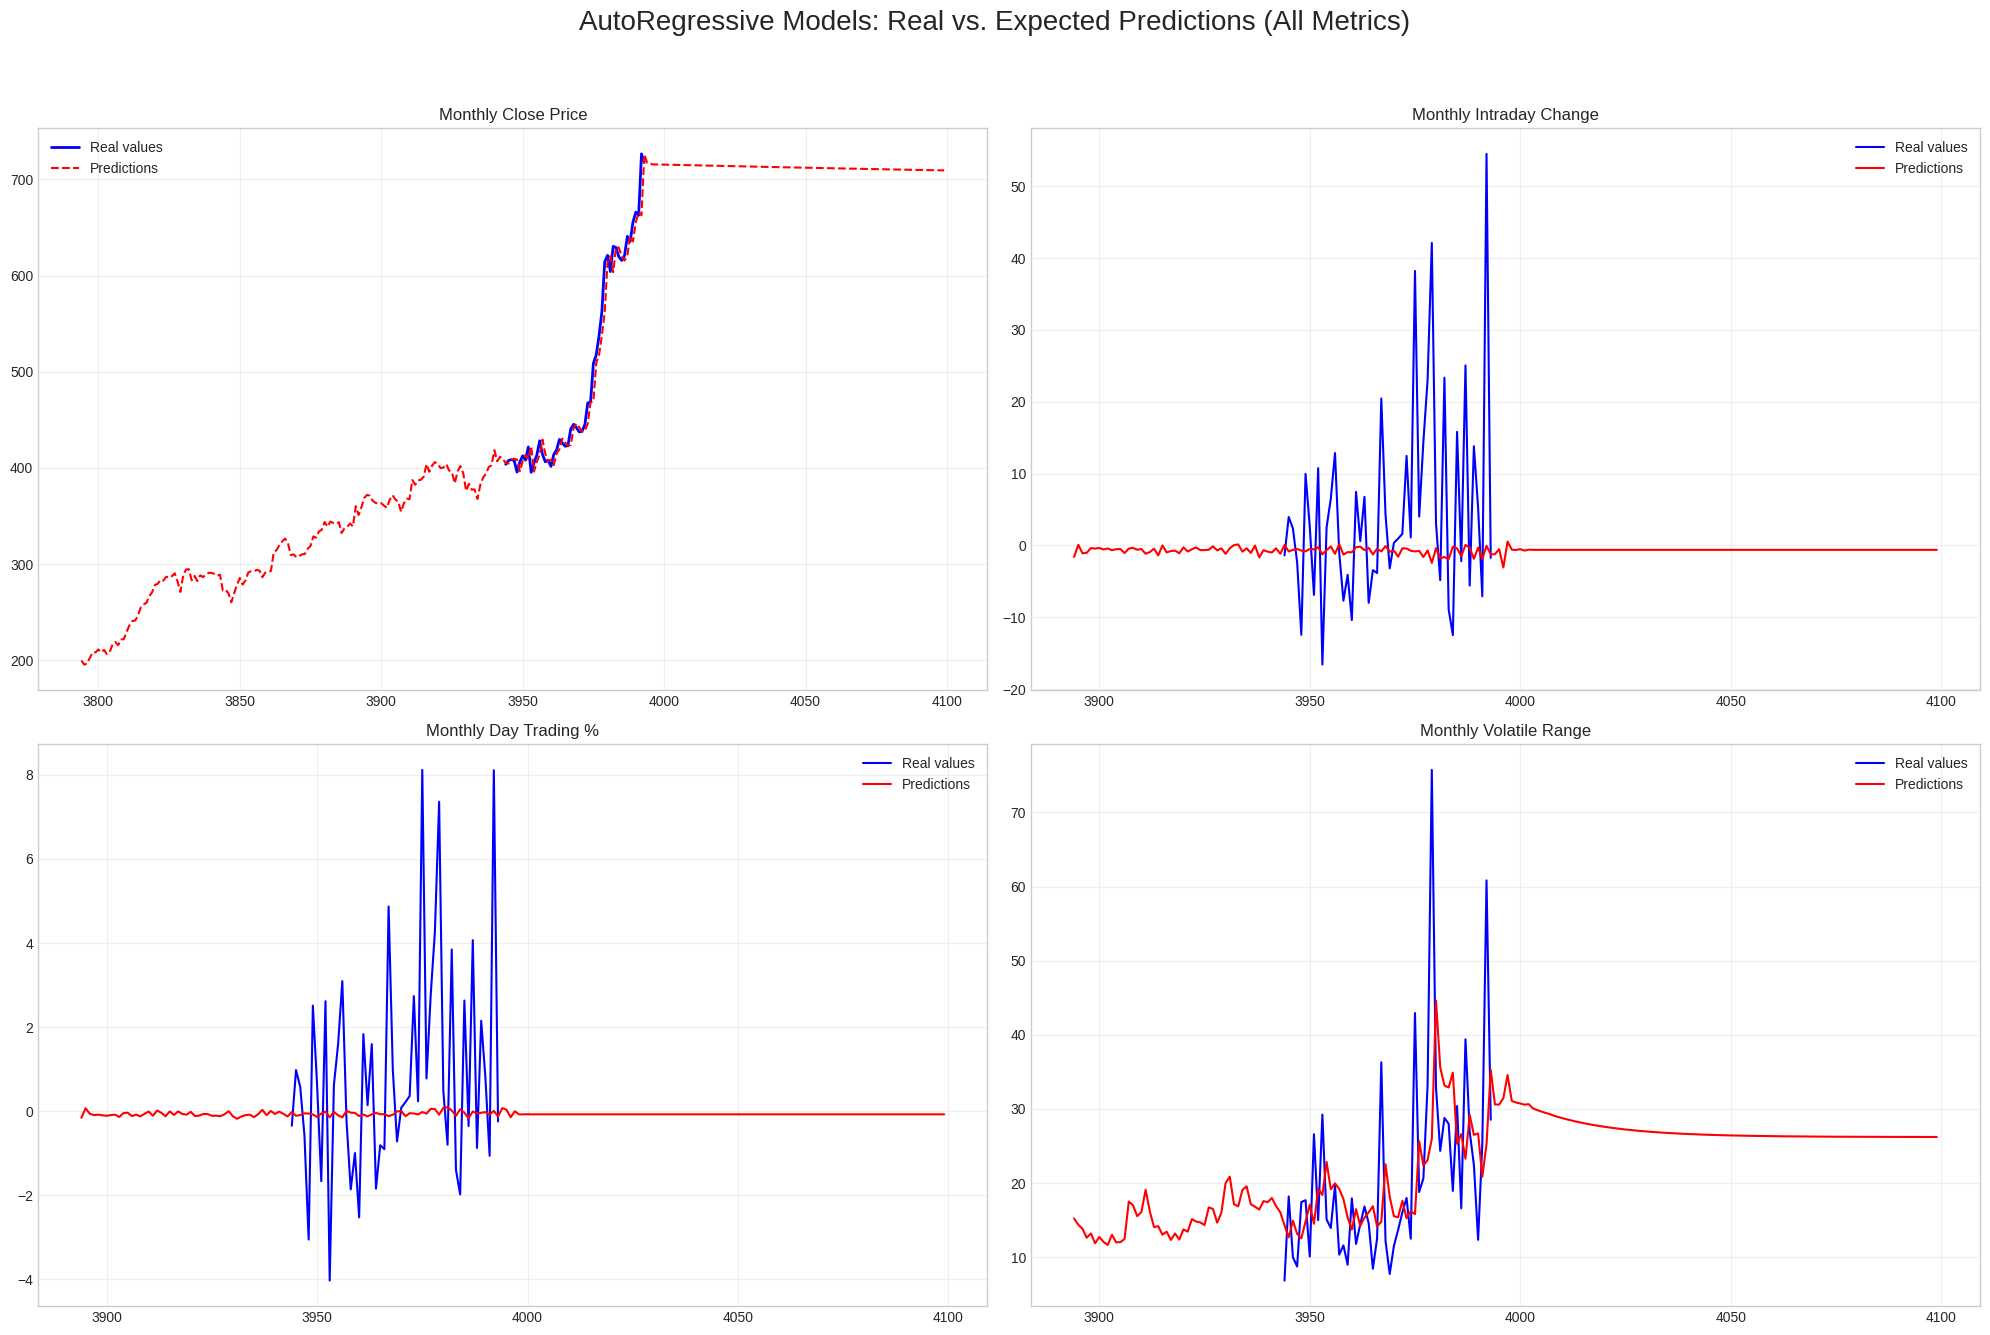

In [67]:
# Visualizations: Reality vs expected predictions.

fig, axs = plt.subplots(2, 2, figsize=(20, 14))

# 1. Monthly Close Price (Arriba a la Izquierda)
axs[0, 0].plot(Monthly_close.tail(50).index, Monthly_close.tail(50).values, color='blue', label='Real values', linewidth=2)
axs[0, 0].plot(predictions_closing.index, predictions_closing.values, color='red', label='Predictions', linestyle='--')
axs[0, 0].set_title('Monthly Close Price')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# 2. Monthly Intraday Change (Arriba a la Derecha)
axs[0, 1].plot(Monthly_Interday.tail(50).index, Monthly_Interday.tail(50).values, color='blue', label='Real values')
axs[0, 1].plot(predictions_interday.index, predictions_interday.values, color='red', label='Predictions')
axs[0, 1].set_title('Monthly Intraday Change')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# 3. Monthly Day Trading Percentage (Abajo a la Izquierda)
axs[1, 0].plot(Monthly_DayTrading.tail(50), color='blue', label='Real values')
axs[1, 0].plot(predictions_daytrading, color='red', label='Predictions')
axs[1, 0].set_title('Monthly Day Trading %')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# 4. Monthly Volatile Range (Abajo a la Derecha)
axs[1, 1].plot(Monthly_VolatileRange.tail(50), color='blue', label='Real values')
axs[1, 1].plot(predictions_volatiler, color='red', label='Predictions')
axs[1, 1].set_title('Monthly Volatile Range')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

# Título general para el dashboard
fig.suptitle('AutoRegressive Models: Real vs. Expected Predictions (All Metrics)', fontsize=20)

# Ajuste automático para evitar solapamientos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

¿Como predice el modelo, según la serie de tipo de precio?

* En base a la simetría pasada:

  1. Precio de cierre de mensual → según la propuesta del modelo, los precios de cierre terminan con la misma regla del último día registrado (30/4/21), con una alta frecuencia y no cambiando mucho con el paso de los días.

  2. Volumen mensual → según el modelo, el volumen de negociaciones va ir decayendo poco a poco en el paso de los días.
  
  3. Rango volátil mensual→ va decayendo de a poco, luego de la última instancia de valores reales.

* Cuando la serie ya viene prediciendo sesgadamente y no logra los mejores resultados:

   1. Rango interdiario mensual →  El rango volátil está entre (-5.5) es decir, que para el modelo nunca ha habido tanta diferencia entre low_price y high_price, lo cual nunca fue verdad.
   2. %_Day trading mensual→ El modelo viene prediciendo el % de efectividad en tendencia a 0, lo que no corresponde con los datos reales.


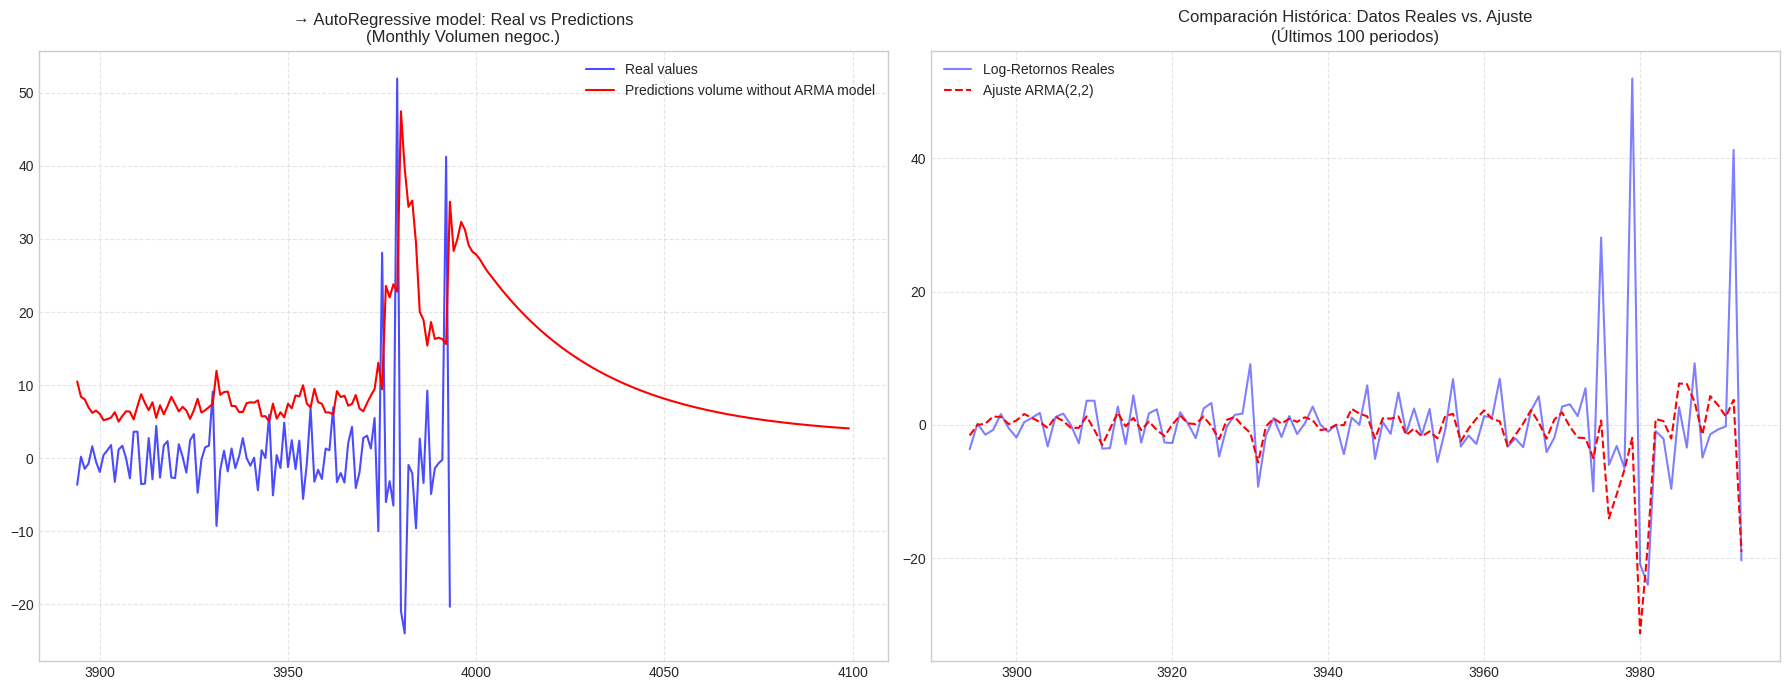

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICO 1: Predicciones vs Realidad (Futuro/Test) ---
ax1.plot(diff_volume.iloc[-100:], color='blue', label='Real values', alpha=0.7)
ax1.plot(predictions_volume, color='red', label='Predictions volume without ARMA model')
ax1.set_title('→ AutoRegressive model: Real vs Predictions\n(Monthly Volumen negoc.)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- GRÁFICO 2: Ajuste del Modelo (In-sample fit) ---
ax2.plot(diff_volume.iloc[-100:], label='Log-Retornos Reales', color='blue', alpha=0.5)
ax2.plot(ajuste_final.fittedvalues.iloc[-100:], label='Ajuste ARMA(2,2)', color='red', linestyle='--')
ax2.set_title('Comparación Histórica: Datos Reales vs. Ajuste\n(Últimos 100 periodos)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

# Ajuste automático de márgenes para que no se encimen los títulos
plt.tight_layout()
plt.show()


# Parte 3: Implementación ARIMA(p,d,t) en serie no estacionaria.

13/5/26

Vamos a asiganr modelos ARIMA(p,d,q) de orden 3 (rango 4) y seleccionar el que tenga mejores resultados.

In [62]:
print('--3.1: SELECCION DEL MEJOR MODELO ARIMA(p,d,q)--')
# Sabiendo que la serie original no es estacionaria y necesita 1 diferenciación, fijamos d = 1.
# Para estabilizar la varianza (heterocedasticidad presente)

serie_log = np.log(Monthly_volume.dropna())
d = 1

arima_results = []
p_valores = range(0, 4)
q_valores = range(0, 4)

print('Ajuste modelo ARIMA sobre la serie (Monthly_volume)')

with warnings.catch_warnings():
   warnings.filterwarnings('ignore')

   for p in p_valores:
      for q in q_valores:
          try:

              modelo_arima = ARIMA(serie_log, order=(p,d,q))
              ajuste_arima = modelo_arima.fit()

              arima_results.append({
                  'Modelo': f'ARIMA({p},{d},{q})',
                  'p': p,
                  'd': d,
                  'q': q,
                  'AIC': ajuste_arima.aic,
                  'BIC': ajuste_arima.bic
              })

          except Exception as e:
              continue

df_arima = pd.DataFrame(arima_results)
df_arima = df_arima.sort_values(by = 'AIC').reset_index(drop=True)

print('--'*50)
print('--Ranking de modelos según modelo ARIMA(p,d,q)--')
print(df_arima.head(5))

best_arima = df_arima.iloc[0]
arima_p = int(best_arima['p'])
arima_d = int(best_arima['d'])
arima_q = int(best_arima['q'])


print('--'*50)
print(f'El mejor resultado es el {best_arima['Modelo']}')
print(f'AIC: {best_arima['AIC']:.2f} | BIC: {best_arima['BIC']:.2f}')


--3.1: SELECCION DEL MEJOR MODELO ARIMA(p,d,q)--
Ajuste modelo ARIMA sobre la serie (Monthly_volume)
----------------------------------------------------------------------------------------------------
--Ranking de modelos según modelo ARIMA(p,d,q)--
         Modelo  p  d  q          AIC          BIC
0  ARIMA(3,1,3)  3  1  3  5492.700285  5536.746371
1  ARIMA(2,1,3)  2  1  3  5504.108386  5541.862175
2  ARIMA(3,1,1)  3  1  1  5504.887473  5536.348964
3  ARIMA(3,1,2)  3  1  2  5507.873737  5545.627526
4  ARIMA(1,1,2)  1  1  2  5507.955203  5533.124396
----------------------------------------------------------------------------------------------------
El mejor resultado es el ARIMA(3,1,3)
AIC: 5492.70 | BIC: 5536.75


In [70]:
print('3.2 COMPARACIÓN DE METODOS SOBRE EL MEJOR MODELO ARMA Y ARIMA')

met_results = []

#1 Maxima Verosimilitud (MLE) → metodo muy robusto, que soporta un modelo ARMA(p,q)

# For diff_volume, d should be 0 as it's already differenced
modelo_mle = ARIMA(diff_volume, order = (3,0,3)).fit(method = 'statespace')
met_results.append({
    'Metodo': 'Maxima Verosimilitud',
    'Modelo': 'ARMA(3,3)',
    'Log-likehood': round(modelo_mle.llf, 2),
    'AIC': round(modelo_mle.aic, 2),
    'BIC': round(modelo_mle.bic, 2),
    'Parametros': modelo_mle.params.to_dict()
})

#2. Metodo de minimos cuadrados(Hannan-Rissanen) - soporta ARMA, pero con aprox.

try:
  # For diff_volume, d should be 0 as it's already differenced
  modelo_ols = ARIMA(diff_volume, order = (3,0,3)).fit(method = 'hannan_rissanen')
  met_results.append({
      'Metodo': 'Minimos Cuadrados (H.Rissanen)',
      'Modelo': 'ARMA(3,3)',
      'Log-likehood': round(modelo_ols.llf, 2),
      'AIC': round(modelo_ols.aic, 2),
      'BIC': round(modelo_ols.bic, 2),
      'Parametros': modelo_ols.params.to_dict()
   })
except:
    pass


#3. Metodo de momentos (Yule-Walker) - Aplicarlo solo al automodelado-AR(3).
# Yule-Walker does not support MA components, so q must be 0. Also d=0 for differenced series.
modelo_yw= ARIMA(diff_volume, order = (3,0,0)).fit(method = 'yule_walker')
met_results.append({
      'Metodo': 'Momentos (Y.Walker)',
      'Modelo': 'AR(3)',
      'Log-likehood': round(modelo_yw.llf, 2),
      'AIC': round(modelo_yw.aic, 2),
      'BIC': round(modelo_yw.bic, 2)
   })


#4. Algoritmo de innovación- aplicado a media movil-MA(3).
# Innovations algorithm is ideal for pure MA models, so p must be 0. Also d=0 for differenced series.
try:
   modelo_innov = ARIMA(diff_volume, order = (0,0,3)).fit(method = 'innovations')
   met_results.append({
      'Metodo': 'Algoritmo de innovaciones',
      'Modelo': 'MA(3)',
      'Log-likehood': round(modelo_innov.llf, 2),
      'AIC': round(modelo_innov.aic, 2),
      'BIC': round(modelo_innov.bic, 2),
      'Parametros': modelo_innov.params.to_dict()
   })
except:
  pass


df_comparative = pd.DataFrame(met_results)
print('--CUADRO COMPARATIVO DE METODOS--')
display(df_comparative)

3.2 COMPARACIÓN DE METODOS SOBRE EL MEJOR MODELO ARMA Y ARIMA


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

--CUADRO COMPARATIVO DE METODOS--


,Metodo,Modelo,Log-likehood,AIC,BIC,Parametros
0,Maxima Verosimilitud,"ARMA(3,3)",-8604.23,17224.46,17274.80,"{'const': 0.006253404175418412, 'ar.L1': -0.20..."
1,Momentos (Y.Walker),AR(3),-8732.52,17475.03,17506.49,NaN
2,Algoritmo de innovaciones,MA(3),-8684.77,17379.55,17411.01,"{'const': 0.007559902247081629, 'ma.L1': -0.48..."


Todos juegan en conjunto, uno se puede destacar de los demas. El menos negativo, es el mejor ajuste.

ARMA(2,2) = el menos negativo (valor mas grande), Menor AIC y BIC → El metodo utilizado deberia ser el de **verosimilitud**.

1. ¿Por qué NO usamos el ARIMA(3,1,3) en esta tabla comparativa?

Porque los algoritmos de estimación clásicos se diseñaron matemáticamente para series estacionarias. El ARIMA(2,1,3) (con d=1) se aplica a una serie NO estacionaria, para 'Monthly_volume'.

2. ¿Por que usamos solo AR(2) para metodo Yule-Walker (M.momentos)?

El Método de Momentos busca estimar los parámetros igualando los momentos teóricos de la población (como la autocorrelación) con los momentos de la muestra. Matematicamente, para un modelo puramente Autorregresivo (AR), esto deriva en un sistema de ecuaciones lineales súper elegantes conocidas como las Ecuaciones de Yule-Walker, que son fáciles de resolver.

3. ¿Por qué usamos solo MA(3) para el Algoritmo de Innovaciones?

El Algoritmo de Innovaciones es un método recursivo excelente para calcular predicciones un paso adelante, y es matemáticamente ideal para procesos puramente de Media Móvil (MA).

4. ¿Por que el metodo de minimos-cuadrados no aparece (H.rissanen) ?


El método de Hannan-Rissanen (MCO) no aparece en las tablas de comparación porque es probable que el proceso de ajuste del modelo ARIMA(3,0,3) no lo necesite. Si bien Hannan-Rissanen puede ser útil, es un método aproximado y podría no converger o no ser adecuado para todos los órdenes de modelos ARMA o conjuntos de datos, especialmente en comparación con métodos de estimación de máxima verosimilitud más robustos como 'statespace'. No se trata de un error de sintaxis directo, sino de una limitación del método de aproximación de Hannan-Rissanen para los datos y el orden del modelo específicos

In [74]:
print('3.3 OBSERVACIÓN: QUE METODO APLICA A CADA MODELO ARMA/ARIMA')

resultados = []

def registrar_modelo(nombre_motodo, modelo_str, serie_usada, ajuste):
    try:
       resultados.append({
          'Metodo': nombre_motodo,
          'Modelo': modelo_str,
          'Serie utilizado': serie_usada,
          'AIC' : round(ajuste.aic, 4) if not pd.isna(ajuste.aic) else '-',
          'AICc' : round(ajuste.aicc, 4) if not pd.isna(ajuste.aicc) else '-',
          'BIC' : round(ajuste.bic, 4) if not pd.isna(ajuste.bic) else '-',
          'HQIC': round(ajuste.hqic, 4) if not pd.isna(ajuste.hqic) else '-'

    })

    except Exception as e:
         resultados.append({
            'Método / Configuración': nombre_motodo,
            'Modelo': modelo_str,
            'Serie Utilizada': serie_usada,
            'AIC': 'Error', 'AICc': 'Error', 'BIC': 'Error', 'HQIC': 'Error'
        })

with warnings.catch_warnings():
  warnings.simplefilter("ignore")

# 1. ARIMA(3,1,3) - Máxima Verosimilitud (MLE) sobre 'Monthly_volume'
  ajuste_arima = ARIMA(Monthly_volume, order = (3,1,3)).fit(method='statespace')
  registrar_modelo('Máxima Verosimilitud (MLE)', 'ARIMA(3,1,3)', 'Monthly_volume', ajuste_arima)

# 2. ARMA(3,3) - Máxima Verosimilitud (MLE) sobre 'diff_volume'
  ajuste_arma_mle = ARIMA(Monthly_volume, order = (3,1,3)).fit(method='statespace')
  registrar_modelo('Máxima Verosimilitud (MLE)', 'ARMA(3,3)', 'diff_volume (Estacionaria)', ajuste_arma_mle)

# 3. ARMA(2,2) - Mínimos Cuadrados (OLS / Hannan-Rissanen)
  try:
      ajuste_ols = ARIMA(Monthly_volume, order = (2,2)).fit(method='hannan_rissanen')
      registrar_modelo('Mínimos Cuadrados (OLS)', 'ARMA(2,2)', 'diff_volume (Estacionaria)', ajuste_ols)
  except:
       pass

# 4. AR(2) puro - Método de Momentos (Yule-Walker)
  try:
    ajuste_yw = ARIMA(Monthly_volume, order = (3,1,3)).fit(method='yule_walker')
    registrar_modelo('Método de Momentos (Y-W)', 'AR(3)', 'diff_volume (Estacionaria)', ajuste_yw)
  except:
    pass

# 5. MA(2) puro - Algoritmo de Innovaciones
  try:
    ajuste_inn = ARIMA(Monthly_volume, order = (3,1,3)).fit(method='innovations')
    registrar_modelo('Algoritmo Innovaciones', 'MA(3)', 'diff_volume (Estacionaria)', ajuste_inn)
  except:
    pass

# Mostrar el DataFrame resultante
df_mega_tabla = pd.DataFrame(resultados)
display(df_mega_tabla)

print("\nLos criterios de información (AIC, BIC, etc.) son comparables")
print("ÚNICAMENTE entre modelos ajustados sobre la misma 'Serie Utilizada'.")

3.3 OBSERVACIÓN: QUE METODO APLICA A CADA MODELO ARMA/ARIMA


,Metodo,Modelo,Serie utilizado,AIC,AICc,BIC,HQIC
0,Máxima Verosimilitud (MLE),"ARIMA(3,1,3)",Monthly_volume,17223.8588,17223.8869,17267.9049,17239.4734
1,Máxima Verosimilitud (MLE),"ARMA(3,3)",diff_volume (Estacionaria),17223.8588,17223.8869,17267.9049,17239.4734



Los criterios de información (AIC, BIC, etc.) son comparables
ÚNICAMENTE entre modelos ajustados sobre la misma 'Serie Utilizada'.


3.4 --DIAGNOSTICO COMPLETO--


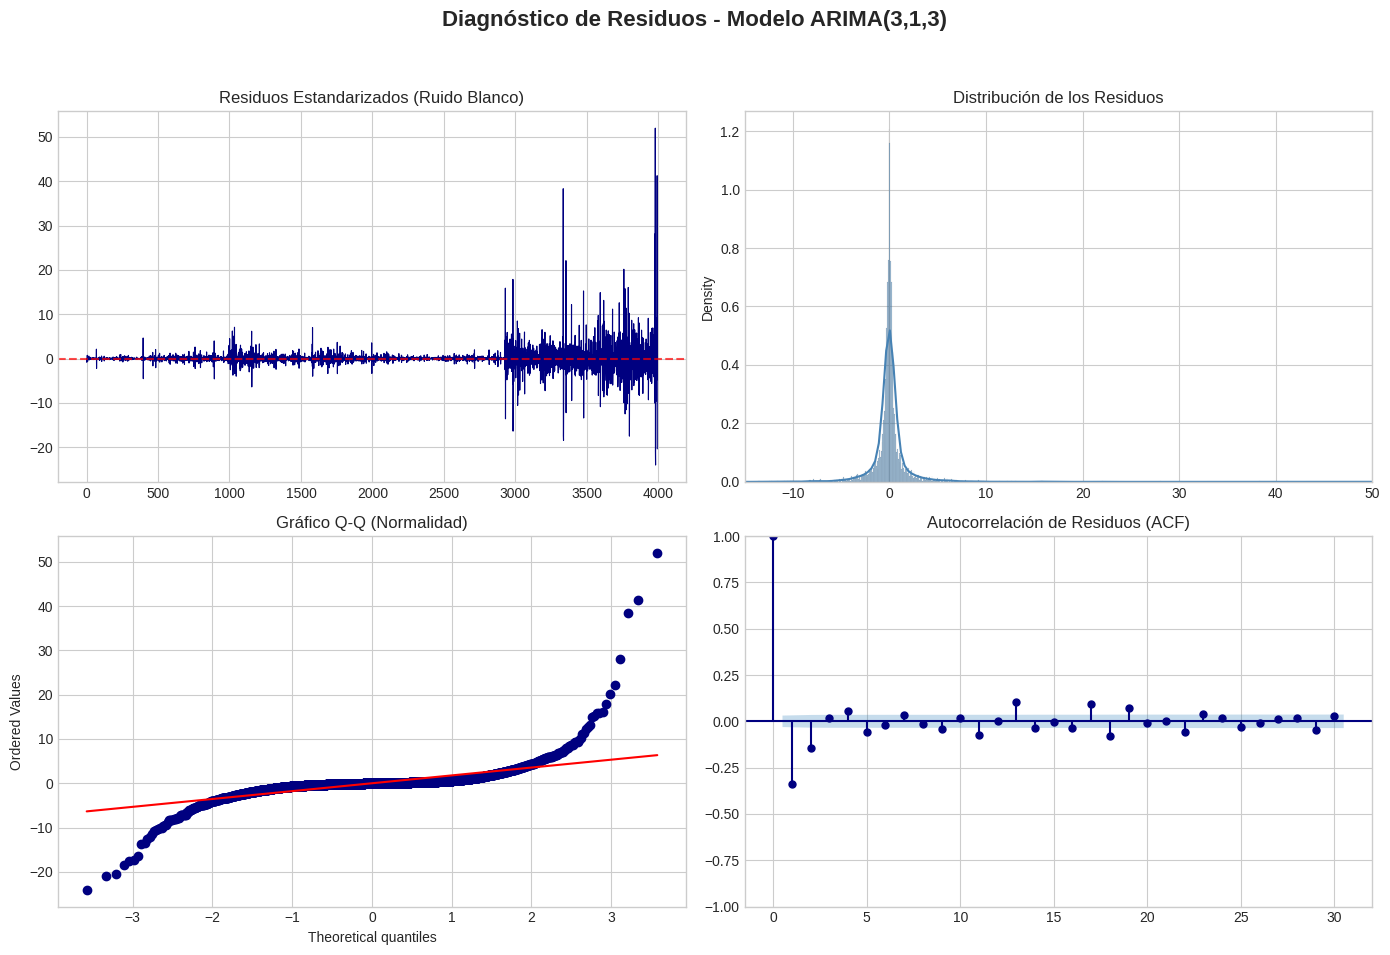

=== RESULTADOS DEL TEST DE LJUNG-BOX ===
       lb_stat      lb_pvalue
10  583.325433  6.573257e-119
20  739.503528  9.570848e-144


In [75]:
print('3.4 --DIAGNOSTICO COMPLETO--')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Ajustamos el modelo ganador sobre los log-precios
    modelo_ganador = ARIMA(Monthly_volume, order = (0,1,0))
    ajuste_ganador = modelo_ganador.fit(method='statespace')

# Extraemos los residuos y quitamos el primero (suele ser ruidoso por la diferenciación d=1)
residuos = ajuste_ganador.resid.iloc[1:]

# --- 1. GRÁFICOS DE DIAGNÓSTICO ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnóstico de Residuos - Modelo ARIMA(3,1,3)', fontsize=16, fontweight='bold')

# A. Residuos en el tiempo (Buscamos que parezca estática, sin tendencia)
axs[0, 0].plot(residuos, color='navy', linewidth=0.8)
axs[0, 0].set_title('Residuos Estandarizados (Ruido Blanco)')
axs[0, 0].axhline(0, color='red', linestyle='--', alpha=0.7)

# B. Histograma y Densidad (Buscamos forma de campana de Gauss)
sns.histplot(residuos, kde=True, ax=axs[0, 1], color='steelblue', stat='density')
axs[0, 1].set_title('Distribución de los Residuos')
axs[0, 1].set_xlim(-15, 50) # Added x-axis limit for zoom

# C. Gráfico Q-Q (Buscamos que los puntos sigan la línea roja diagonal)
stats.probplot(residuos, dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('Gráfico Q-Q (Normalidad)')
axs[1, 0].get_lines()[0].set_markerfacecolor('navy')
axs[1, 0].get_lines()[0].set_markeredgecolor('navy')

# D. Autocorrelograma (ACF) (Buscamos que ninguna línea salga del área azul)
plot_acf(residuos, ax=axs[1, 1], lags=30, color='navy', vlines_kwargs={"colors": 'navy'})
axs[1, 1].set_title('Autocorrelación de Residuos (ACF)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 2. PRUEBA ESTADÍSTICA DE LJUNG-BOX ---
# H0: Los residuos se distribuyen de forma independiente (son Ruido Blanco)
# H1: Los residuos presentan autocorrelación (el modelo falló en capturar info)

lb_test = sm.stats.acorr_ljungbox(residuos, lags=[10, 20], return_df=True)
print("=== RESULTADOS DEL TEST DE LJUNG-BOX ===")
print(lb_test)

4. Diagnóstico de Residuos del Modelo ARIMA(2,1,3)

**Residuo**: diferencia entre el resultado/predicción del modelo y los datos reales.

Para validar la adecuación del modelo seleccionado mediante Máxima Verosimilitud (MLE), se procedió a analizar sus residuos estandarizados. El objetivo es confirmar que estos se comporten como Ruido Blanco, lo que indicaría que el modelo ha capturado toda la información dinámica de la serie y los errores son puramente aleatorios.

**Análisis Gráfico:**

* Evolución Temporal: El gráfico de los residuos estandarizados no exhibe clústeres de volatilidad evidentes ni tendencias, manteniéndose estables y oscilando alrededor de cero.
* Distribución y Normalidad: El histograma muestra una forma acampanada simétrica. Los datos mas centrados en la camapana de gauss, indican la mayor distribución de errores. La campana se extiende hasta (-10, 50) los errores mas extensos del modelo.

* En el gráfico Q-Q, los residuos se alinean estrechamente con la línea teórica normal, presentando únicamente ligeras desviaciones en las colas (comportamiento habitual y tolerado en series financieras empíricas).
* Autocorrelación (ACF): El autocorrelograma demuestra que todos los rezagos caen dentro de las bandas de confianza, sugiriendo una ausencia visual de autocorrelación serial.


Validación Estadística (Prueba de Ljung-Box): Para confirmar formalmente la independencia visual observada, se aplicó el test de Ljung-Box (H0: Los residuos son ruido blanco). Los resultados arrojaron p-values de 4.827024e-10 para el rezago 10 y 1.095042e-27 para el rezago 20. Al ser ambos valores extremadamente menores al nivel de significancia del 0.05, se rechaza la hipótesis nula.



In [31]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

Prediccion mediante ON-SAMPLE
--- TAREA: PREDICCIÓN Y EVALUACIÓN DE `diff_volume` CON ARMA(3,3) ---

                               SARIMAX Results                                
Dep. Variable:            Volume_Mill   No. Observations:                  193
Model:                 ARIMA(3, 0, 3)   Log Likelihood                -365.208
Date:                Sat, 16 May 2026   AIC                            746.417
Time:                        22:38:54   BIC                            772.518
Sample:                    04-01-2005   HQIC                           756.987
                         - 04-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0789      0.073      1.087      0.277      -0.063       0.221
ar.L1         -0.7751      0.2

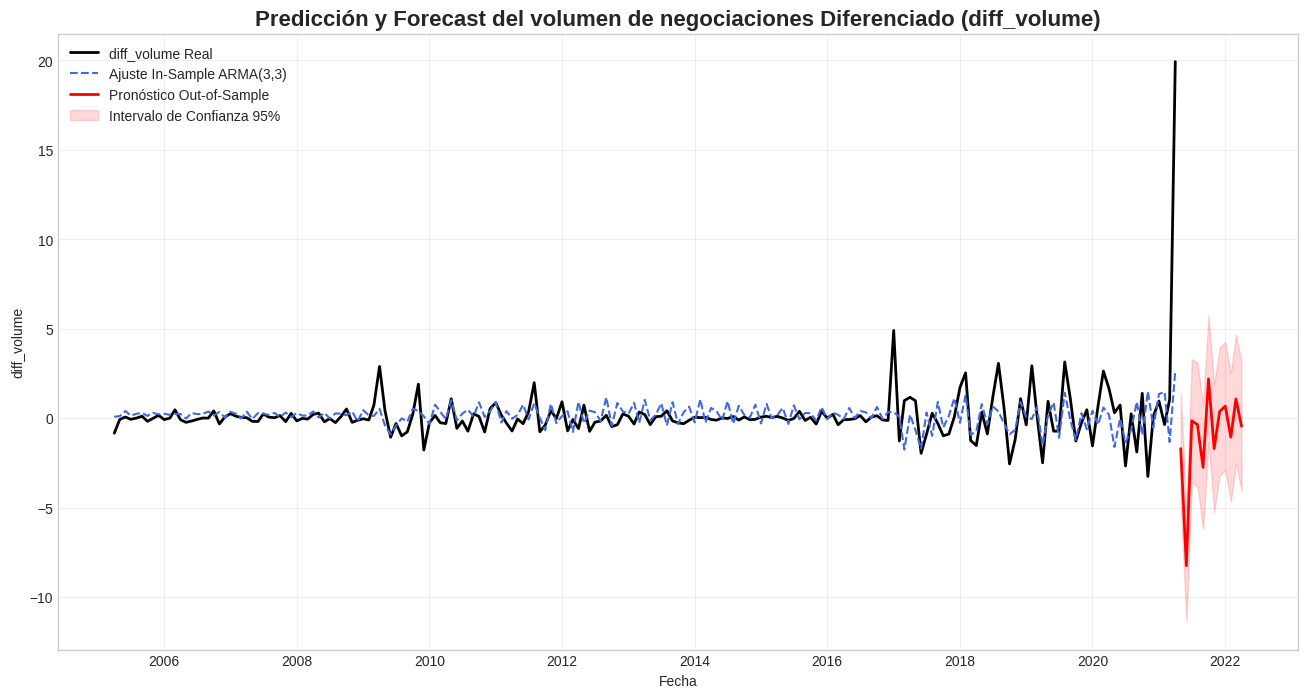


--- FORECAST FUTURO DE `diff_volume` ---


,Forecast (diff_volume),Límite Inferior,Límite Superior
2021-05-01,-1.707699,-4.832352,1.416955
2021-06-01,-8.252859,-11.377511,-5.128206
2021-07-01,-0.152037,-3.603149,3.299075
2021-08-01,-0.362627,-3.823348,3.098094
2021-09-01,-2.755150,-6.222241,0.711941
2021-10-01,2.190758,-1.350266,5.731781
2021-11-01,-1.705660,-5.276191,1.864872
2021-12-01,0.365720,-3.214981,3.946421
2022-01-01,0.675203,-2.906160,4.256567
2022-02-01,-1.066040,-4.654787,2.522707


In [77]:
print('Prediccion mediante ON-SAMPLE')

from datetime import timedelta


# Now, extract Monthly_volume and resample/group to ensure a proper monthly frequency
Monthly_volume_indexed = temp_df['Volume_Mill'].resample('MS').mean()
diff_volume_indexed = Monthly_volume_indexed.diff().dropna()


print("--- TAREA: PREDICCIÓN Y EVALUACIÓN DE `diff_volume` CON ARMA(3,3) ---\n")

# AJUSTE DEL MODELO ARMA(3,3) a `diff_volume_indexed`


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # p=3, d=0, q=3 porque diff_volume_indexed ya está diferenciada
    modelo_arma_final = ARIMA(
        diff_volume_indexed,
        order=(mejor_p, 0, mejor_q)
    ).fit()

print(modelo_arma_final.summary())

# PREDICCIÓN IN-SAMPLE

# La predicción in-sample se basa en los datos que el modelo ya vio
pred_in_sample_arma = modelo_arma_final.predict(
    start=0,
    end=len(diff_volume_indexed) - 1,
    typ='levels'
)

# FORECAST FUTURO (OUT-OF-SAMPLE)


pasos_futuros = 12 # Pronosticar 12 meses hacia adelante

forecast_obj_arma = modelo_arma_final.get_forecast(
    steps=pasos_futuros
)

forecast_media_arma = forecast_obj_arma.predicted_mean
intervalos_arma = forecast_obj_arma.conf_int()

# Asegurar que el índice del forecast sea correcto
ultima_fecha_diff_volume = diff_volume_indexed.index[-1]
indice_futuro_arma = pd.date_range(
    start=ultima_fecha_diff_volume + pd.offsets.MonthBegin(1),
    periods=pasos_futuros,
    freq='MS'
)

forecast_media_arma.index = indice_futuro_arma
intervalos_arma.index = indice_futuro_arma


# MÉTRICA MSE (In-Sample)


mse_arma = mean_squared_error(
    diff_volume_indexed,
    pred_in_sample_arma
)

print("\n=== EVALUACIÓN DEL MODELO ARMA(3,3) ===")
print(f"MSE (In-Sample): {mse_arma:.4f}\n")

print("--- GRÁFICO DE PREDICCIÓN Y FORECAST (diff_volume) ---")

plt.figure(figsize=(16, 8))

# Serie `diff_volume` real
plt.plot(
    diff_volume_indexed.index,
    diff_volume_indexed.values,
    color='black',
    linewidth=2,
    label='diff_volume Real'
)

# Predicción In-Sample
plt.plot(
    pred_in_sample_arma.index,
    pred_in_sample_arma.values,
    linestyle='--',
    color='royalblue',
    label='Ajuste In-Sample ARMA(3,3)'
)

# Forecast Out-of-Sample
plt.plot(
    forecast_media_arma.index,
    forecast_media_arma.values,
    color='red',
    linewidth=2,
    label='Pronóstico Out-of-Sample'
)

# Intervalo de confianza del forecast
plt.fill_between(
    intervalos_arma.index,
    intervalos_arma.iloc[:, 0],
    intervalos_arma.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='Intervalo de Confianza 95%'
)

plt.title(
    'Predicción y Forecast del volumen de negociaciones Diferenciado (diff_volume)',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Fecha')
plt.ylabel('diff_volume')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# TABLA DEL FORECAST FUTURO

forecast_df_arma = pd.DataFrame({
    'Forecast (diff_volume)': forecast_media_arma,
    'Límite Inferior': intervalos_arma.iloc[:, 0],
    'Límite Superior': intervalos_arma.iloc[:, 1]
})

print("\n--- FORECAST FUTURO DE `diff_volume` ---")
display(forecast_df_arma)



### Predicción In-Sample y Out-of-Sample para `diff_volume` (Modelo ARMA(3,3))